# Dist 4 Analysis

This notebook analyzes the participant data in `Experiment1/data/dist 4/data`.
The workflow follows the same structure as `analysis-drop.ipynb`, but it is adapted to the actual condition set and survey fields in this dataset.

In [105]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", None)

## 1. Data Loading and Preprocessing

In [106]:
DATA_DIR = Path("../data/0306/data")
CSV_PATTERN = "user_*.csv"


def extract_condition_number(condition_id):
    if pd.isna(condition_id):
        return np.nan

    for part in str(condition_id).split("_"):
        if part.isdigit():
            return int(part)

    return np.nan


def load_participant_data(file_path):
    df = pd.read_csv(file_path)
    df["source_file"] = file_path.name

    if "participant_id" not in df.columns or df["participant_id"].isna().all():
        participant_id = file_path.stem.split("_")[1]
        df["participant_id"] = participant_id

    if "condition_id" in df.columns:
        df["condition_id"] = df["condition_id"].fillna("unknown")
        df["condition_number"] = df["condition_id"].apply(extract_condition_number)
    else:
        df["condition_id"] = "unknown"
        df["condition_number"] = np.nan

    return df


csv_files = sorted(DATA_DIR.glob(CSV_PATTERN))
print(f"Using data directory: {DATA_DIR.resolve()}")
print(f"Found {len(csv_files)} participant CSV files")
print("Sample files:")
for file_path in csv_files[:10]:
    print(f"  - {file_path.name}")
if len(csv_files) > 10:
    print(f"  ... and {len(csv_files) - 10} more")

all_data = [load_participant_data(file_path) for file_path in csv_files]
combined_data = pd.concat(all_data, ignore_index=True)

before_participants = combined_data["participant_id"].nunique(dropna=True)
combined_data = combined_data[combined_data["participant_id"].notna()].copy()
combined_data = combined_data[~combined_data["participant_id"].astype(str).str.lower().eq("test")].copy()
after_participants = combined_data["participant_id"].nunique(dropna=True)

print()
print(f"Combined dataset shape: {combined_data.shape}")
print(f"Participants: {before_participants} -> {after_participants}")

Using data directory: /Users/songwen/Documents/Code Lab/Interact4Trust/Experiment1/data/0306/data
Found 337 participant CSV files
Sample files:
  - user_1772988620005_2026-03-08T16-50-20-005.csv
  - user_5006212406344_2026-03-08T17-02-58-232.csv
  - user_5048725561480001270_2026-03-08T16-52-57-001.csv
  - user_5076480415502114006_2026-03-08T16-36-52-224.csv
  - user_509831025837711_2026-03-08T17-38-57-526.csv
  - user_51264910828425_2026-03-08T18-00-38-693.csv
  - user_5131270018821_2026-03-08T17-14-25-674.csv
  - user_517616468718_2026-03-08T17-05-13-382.csv
  - user_5204168193768041249_2026-03-08T17-42-14-060.csv
  - user_521523651500159069_2026-03-08T18-14-24-612.csv
  ... and 327 more

Combined dataset shape: (10732, 79)
Participants: 337 -> 337


In [107]:
print("Column names:")
print(combined_data.columns.tolist())

print("\nTrial type counts:")
print(combined_data["trial_type"].value_counts(dropna=False).to_string())

condition_lookup = (
    combined_data.loc[combined_data["condition_number"].notna(), ["condition_number", "condition_name", "condition_id"]]
    .drop_duplicates()
    .sort_values("condition_number")
    .reset_index(drop=True)
)

print("\nConditions present in this dataset:")
display(condition_lookup)

Column names:
['city_a_color', 'city_a_estimate', 'city_a_label', 'city_b_color', 'city_b_estimate', 'city_b_label', 'click_events', 'comprehension_ease', 'condition', 'condition_id', 'condition_name', 'confidence_label', 'confidence_rating', 'data_trust', 'device_pixel_ratio', 'display_format', 'effective_screen_width_px', 'end_time', 'failed_audio', 'failed_images', 'failed_video', 'forecast_organization', 'hover_events', 'interaction_log', 'internal_node_id', 'participant_id', 'percent_score', 'phase', 'phase1_complete', 'phase2_complete', 'phase3_complete', 'phase4_complete', 'phase_assignment_log', 'phase_completion', 'phase_dataset_file', 'phase_execution_order', 'phase_key', 'phase_number', 'phase_slot', 'predictions_shown', 'probability_estimate', 'question_order', 'response', 'responses', 'round', 'rt', 'rt_total', 'screen_height', 'screen_width', 'skeptical_rating', 'slider_moved', 'start_time', 'stimulus', 'study_type', 'success', 'time_elapsed', 'time_on_viz', 'timeout', 't

,condition_number,condition_name,condition_id
0,1.0,Baseline,condition_1_baseline
1,2.0,PI Plot,condition_2_pi_plot
2,3.0,Ensemble Plot,condition_3_ensemble
3,4.0,Ensemble + Hover,condition_4_ensemble_hover
4,5.0,PI Plot + Hover,condition_5_pi_hover
5,6.0,PI to Ensemble,condition_6_pi_to_ensemble
6,9.0,Combined PI + Ensemble,condition_9_combined
7,18.0,Glitch Ensemble + Hover,condition_18_glitch_hover
8,19.0,Glitch PI Plot + Hover,condition_19_glitch_pi_hover
9,20.0,Glitch PI to Ensemble,condition_20_glitch_pi_to_ensemble


In [108]:
relevant_trial_types = [
    "prediction-task",
    "vis-literacy",
    "trust-survey",
    "personality-survey",
    "survey-text",
    "survey-multi-choice",
]

relevant_trials = combined_data[combined_data["trial_type"].isin(relevant_trial_types)].copy()
relevant_trials["interaction_freq"] = np.log1p(
    relevant_trials["interaction_log"].fillna("").astype(str).str.len()
)

prediction_data = relevant_trials[relevant_trials["trial_type"] == "prediction-task"].copy()
phase1_data = prediction_data[prediction_data["phase"] == 1].copy()
phase2_data = prediction_data[prediction_data["phase"].isin([2, 3, 4])].copy()

treatment_conditions = sorted(
    int(value)
    for value in phase2_data["condition_number"].dropna().unique()
    if int(value) != 0
)

print(f"Relevant trial rows: {len(relevant_trials)}")
print(f"Prediction rows: {len(prediction_data)}")
print(f"Phase 1 rows: {len(phase1_data)}")
print(f"Treatment (Phases 2-4) rows: {len(phase2_data)}")
print(f"Treatment conditions: {treatment_conditions}")

Relevant trial rows: 4357
Prediction rows: 1340
Phase 1 rows: 335
Treatment (Phases 2-4) rows: 1005
Treatment conditions: [2, 3, 4, 5, 6, 9, 18, 19, 20]


## 2. Basic Statistics Tables by Condition

In [109]:
def create_condition_response_table(data, response_columns):
    rows = []

    grouped = data.groupby(["condition_number", "condition_name"], dropna=False)
    for (condition_number, condition_name), group in grouped:
        row_label = f"{int(condition_number)} - {condition_name}" if pd.notna(condition_number) else str(condition_name)
        row = {"condition": row_label, "participants": group["participant_id"].nunique()}
        for col in response_columns:
            row[col] = group[col].dropna().tolist() if col in group.columns else []
        rows.append(row)

    return pd.DataFrame(rows).set_index("condition")


def summarize_prediction_metrics(data, response_columns):
    summary = (
        data.groupby(["condition_number", "condition_name"], dropna=False)
        .agg(
            participants=("participant_id", "nunique"),
            probability_mean=("probability_estimate", "mean"),
            probability_sd=("probability_estimate", "std"),
            confidence_mean=("confidence_rating", "mean"),
            confidence_sd=("confidence_rating", "std"),
            interaction_mean=("interaction_freq", "mean"),
            interaction_sd=("interaction_freq", "std"),
        )
        .round(2)
        .reset_index()
        .sort_values("condition_number")
    )

    available_columns = [col for col in response_columns if col in data.columns]
    count_summary = (
        data.groupby(["condition_number", "condition_name"], dropna=False)[available_columns]
        .count()
        .reset_index()
        .sort_values("condition_number")
    )

    return summary, count_summary


phase1_columns = ["probability_estimate", "confidence_rating", "travel_choice"]
phase2_columns = [
    "probability_estimate",
    "confidence_rating",
    "travel_choice",
    "data_trust",
    "skeptical_rating",
]

phase1_response_table = create_condition_response_table(phase1_data, phase1_columns)
phase2_response_table = create_condition_response_table(phase2_data, phase2_columns)
phase1_summary, phase1_counts = summarize_prediction_metrics(phase1_data, phase1_columns)
phase2_summary, phase2_counts = summarize_prediction_metrics(phase2_data, phase2_columns)

print("Phase 1 response lists")
display(phase1_response_table)
print("Phase 1 summary")
display(phase1_summary)
print("Phase 1 non-null counts")
display(phase1_counts)

print("Treatment (Phases 2-4) response lists")
display(phase2_response_table)
print("Treatment (Phases 2-4) summary")
display(phase2_summary)
print("Treatment (Phases 2-4) non-null counts")
display(phase2_counts)

Phase 1 response lists


,participants,probability_estimate,confidence_rating,travel_choice
condition,,,,
1 - Baseline,335,"[54.0, 23.0, 71.0, 50.0, 50.0, 51.0, 60.0, 20....","[6.0, 3.0, 3.0, 4.0, 6.0, 2.0, 4.0, 5.0, 4.0, ...","[Talmori, No Preference, Talmori, No Preferenc..."


Phase 1 summary


,condition_number,condition_name,participants,probability_mean,probability_sd,confidence_mean,confidence_sd,interaction_mean,interaction_sd
0,1.0,Baseline,335,49.56,21.81,4.4,1.33,10.8,3.06


Phase 1 non-null counts


...

,participants,probability_estimate,confidence_rating,travel_choice,data_trust,skeptical_rating
condition,,,,,,
2 - PI Plot,114,"[78.0, 44.0, 15.0, 80.0, 50.0, 65.0, 50.0, 55....","[3.0, 3.0, 2.0, 6.0, 2.0, 5.0, 5.0, 4.0, 3.0, ...","[No Preference, Rostiva, Zorvani, No Preferenc...",[],[]
3 - Ensemble Plot,109,"[50.0, 63.0, 80.0, 39.0, 49.0, 50.0, 65.0, 80....","[4.0, 2.0, 4.0, 4.0, 3.0, 4.0, 4.0, 6.0, 1.0, ...","[Kelthar, Kelthar, Rostiva, Zorvani, Qelvane, ...",[],[]
4 - Ensemble + Hover,109,"[58.0, 50.0, 50.0, 54.0, 30.0, 45.0, 54.0, 60....","[3.0, 4.0, 4.0, 3.0, 3.0, 5.0, 4.0, 4.0, 3.0, ...","[Rostiva, No Preference, Pulveth, Kelthar, Pul...",[],[]
5 - PI Plot + Hover,117,"[46.0, 50.0, 30.0, 12.0, 50.0, 11.0, 51.0, 40....","[4.0, 4.0, 2.0, 6.0, 2.0, 6.0, 4.0, 2.0, 5.0, ...","[Rostiva, No Preference, Qelvane, Nexari, Pulv...",[],[]
6 - PI to Ensemble,109,"[72.0, 55.0, 21.0, 42.0, 60.0, 50.0, 84.0, 72....","[3.0, 2.0, 5.0, 4.0, 3.0, 1.0, 6.0, 5.0, 4.0, ...","[No Preference, Rostiva, Zorvani, Nexari, Pulv...",[],[]
9 - Combined PI + Ensemble,112,"[50.0, 52.0, 52.0, 60.0, 25.0, 100.0, 61.0, 50...","[4.0, 2.0, 4.0, 3.0, 2.0, 7.0, 4.0, 3.0, 6.0, ...","[No Preference, Rostiva, Kelthar, Kelthar, Zor...",[],[]
18 - Glitch Ensemble + Hover,112,"[60.0, 46.0, 47.0, 45.0, 100.0, 50.0, 79.0, 84...","[2.0, 4.0, 4.0, 2.0, 5.0, 6.0, 2.0, 4.0, 3.0, ...","[Pulveth, Pulveth, Qelvane, No Preference, Ros...",[],[]
19 - Glitch PI Plot + Hover,109,"[10.0, 50.0, 53.0, 49.0, 40.0, 50.0, 45.0, 35....","[3.0, 4.0, 3.0, 4.0, 3.0, 5.0, 3.0, 4.0, 5.0, ...","[Nexari, No Preference, Pulveth, Nexari, No Pr...",[],[]
20 - Glitch PI to Ensemble,114,"[50.0, 50.0, 52.0, 12.0, 66.0, 50.0, 29.0, 50....","[5.0, 3.0, 6.0, 3.0, 3.0, 2.0, 3.0, 5.0, 4.0, ...","[Pulveth, Kelthar, No Preference, No Preferenc...",[],[]


Treatment (Phases 2-4) summary


,condition_number,condition_name,participants,probability_mean,probability_sd,confidence_mean,confidence_sd,interaction_mean,interaction_sd
0,2.0,PI Plot,114,49.47,23.06,4.30,1.39,10.83,2.46
1,3.0,Ensemble Plot,109,48.02,20.46,3.81,1.51,10.92,2.50
2,4.0,Ensemble + Hover,109,49.47,22.30,4.14,1.35,11.72,1.54
3,5.0,PI Plot + Hover,117,47.03,21.74,4.34,1.36,11.61,1.67
4,6.0,PI to Ensemble,109,46.39,20.35,3.91,1.51,11.68,1.34
5,9.0,Combined PI + Ensemble,112,51.88,21.61,3.77,1.59,11.10,2.80
6,18.0,Glitch Ensemble + Hover,112,46.65,22.62,4.15,1.45,11.78,1.49
7,19.0,Glitch PI Plot + Hover,109,47.28,21.14,4.08,1.39,11.79,1.37
8,20.0,Glitch PI to Ensemble,114,46.67,22.01,4.19,1.32,11.79,1.42


Treatment (Phases 2-4) non-null counts


,condition_number,condition_name,probability_estimate,confidence_rating,travel_choice,data_trust,skeptical_rating
0,2.0,PI Plot,114,114,114,0,0
1,3.0,Ensemble Plot,109,109,109,0,0
2,4.0,Ensemble + Hover,109,109,109,0,0
3,5.0,PI Plot + Hover,117,117,117,0,0
4,6.0,PI to Ensemble,109,109,109,0,0
5,9.0,Combined PI + Ensemble,112,112,112,0,0
6,18.0,Glitch Ensemble + Hover,112,112,112,0,0
7,19.0,Glitch PI Plot + Hover,109,109,109,0,0
8,20.0,Glitch PI to Ensemble,114,114,114,0,0


## 3. Phase 1 to Phase 2-4 Treatment Shift Visualizations

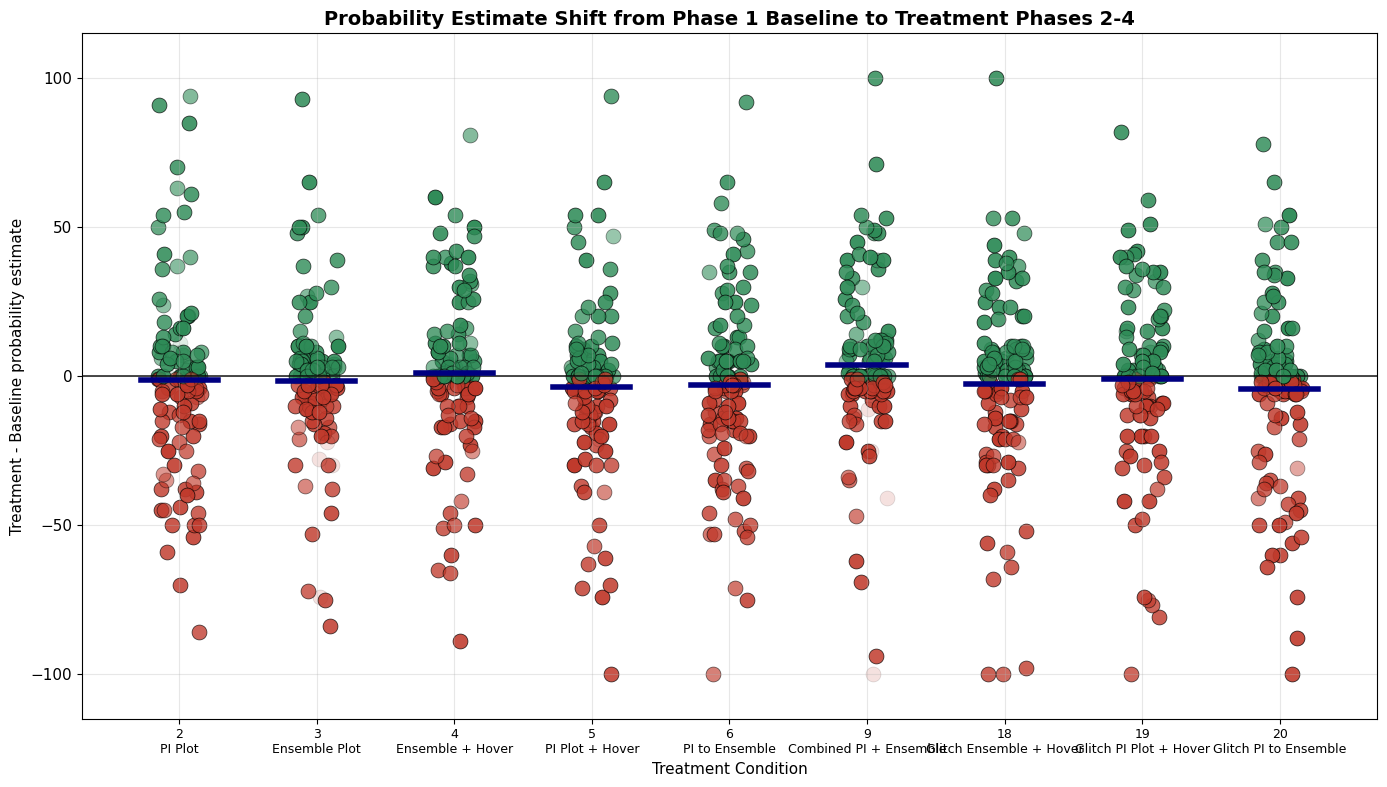

Shift summary for probability_estimate


,condition_number,condition_name,n,mean_shift,sd_shift,mean_interaction
0,2.0,PI Plot,114,-1.50,30.76,10.83
1,3.0,Ensemble Plot,109,-1.51,25.63,10.92
2,4.0,Ensemble + Hover,109,1.11,27.06,11.72
3,5.0,PI Plot + Hover,117,-3.69,26.96,11.61
4,6.0,PI to Ensemble,109,-3.13,29.83,11.68
5,9.0,Combined PI + Ensemble,112,3.73,27.99,11.10
6,18.0,Glitch Ensemble + Hover,112,-2.64,29.87,11.78
7,19.0,Glitch PI Plot + Hover,109,-1.07,28.58,11.79
8,20.0,Glitch PI to Ensemble,114,-4.32,29.66,11.79


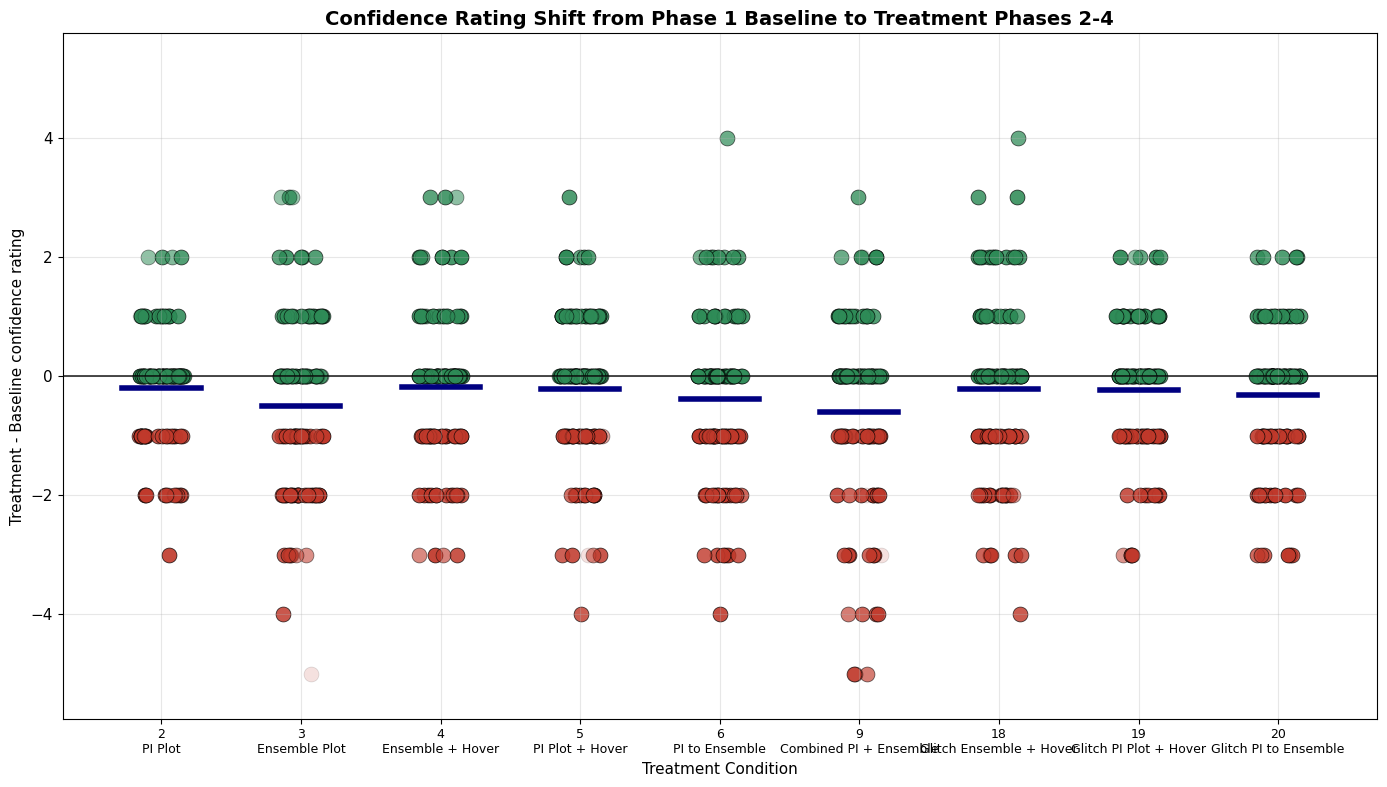

Shift summary for confidence_rating


,condition_number,condition_name,n,mean_shift,sd_shift,mean_interaction
0,2.0,PI Plot,114,-0.20,0.95,10.83
1,3.0,Ensemble Plot,109,-0.51,1.48,10.92
2,4.0,Ensemble + Hover,109,-0.19,1.26,11.72
3,5.0,PI Plot + Hover,117,-0.21,1.20,11.61
4,6.0,PI to Ensemble,109,-0.39,1.35,11.68
5,9.0,Combined PI + Ensemble,112,-0.61,1.54,11.10
6,18.0,Glitch Ensemble + Hover,112,-0.21,1.42,11.78
7,19.0,Glitch PI Plot + Hover,109,-0.23,1.08,11.79
8,20.0,Glitch PI to Ensemble,114,-0.32,1.13,11.79


In [110]:
def create_shift_plot(phase1_data, phase2_data, value_col, title, y_label, y_limits=None):
    baseline = (
        phase1_data.loc[phase1_data[value_col].notna(), ["participant_id", value_col]]
        .drop_duplicates(subset=["participant_id"], keep="last")
        .rename(columns={value_col: f"{value_col}_baseline"})
    )

    treatment = phase2_data[
        phase2_data["condition_number"].notna() & phase2_data[value_col].notna()
    ].copy()
    treatment = treatment[treatment["condition_number"] != 0].copy()

    merged = treatment.merge(baseline, on="participant_id", how="inner")
    if merged.empty:
        print(f"No matched baseline/treatment rows found for {value_col}")
        return None

    merged["shift"] = merged[value_col] - merged[f"{value_col}_baseline"]
    merged["interaction_freq"] = merged["interaction_freq"].fillna(0)

    if merged["interaction_freq"].nunique() > 1:
        freq_min = merged["interaction_freq"].min()
        freq_max = merged["interaction_freq"].max()
        merged["opacity"] = 0.15 + (merged["interaction_freq"] - freq_min) / (freq_max - freq_min) * 0.85
    else:
        merged["opacity"] = 0.75

    summary = (
        merged.groupby(["condition_number", "condition_name"])
        .agg(
            n=("participant_id", "size"),
            mean_shift=("shift", "mean"),
            sd_shift=("shift", "std"),
            mean_interaction=("interaction_freq", "mean"),
        )
        .round(2)
        .reset_index()
        .sort_values("condition_number")
    )

    position_map = {
        int(condition_number): index + 1
        for index, condition_number in enumerate(summary["condition_number"].astype(int).tolist())
    }

    plot_data = merged.copy()
    plot_data["x_position"] = plot_data["condition_number"].astype(int).map(position_map)

    np.random.seed(42)
    jitter = np.random.uniform(-0.16, 0.16, len(plot_data))
    colors = np.where(plot_data["shift"] >= 0, "#2E8B57", "#C0392B")

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axhline(0, color="black", linewidth=1.25, alpha=0.8)

    for x_pos, shift, alpha, color in zip(plot_data["x_position"] + jitter, plot_data["shift"], plot_data["opacity"], colors):
        ax.scatter(x_pos, shift, s=115, alpha=alpha, color=color, edgecolors="black", linewidth=0.5)

    for _, row in summary.iterrows():
        x_pos = position_map[int(row["condition_number"])]
        ax.plot([x_pos - 0.28, x_pos + 0.28], [row["mean_shift"], row["mean_shift"]], color="navy", linewidth=4)

    labels = [
        f"{int(row.condition_number)}\n{row.condition_name}"
        for row in summary.itertuples(index=False)
    ]
    ax.set_xticks(list(position_map.values()))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_xlabel("Treatment Condition")
    ax.set_ylabel(y_label)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)

    if y_limits is not None:
        ax.set_ylim(*y_limits)
    else:
        max_abs_shift = max(abs(plot_data["shift"].min()), abs(plot_data["shift"].max()))
        padded_limit = max_abs_shift * 1.15 if max_abs_shift else 1
        ax.set_ylim(-padded_limit, padded_limit)

    plt.tight_layout()
    plt.show()

    print(f"Shift summary for {value_col}")
    display(summary)
    return plot_data, summary


probability_shift_data, probability_shift_summary = create_shift_plot(
    phase1_data,
    phase2_data,
    value_col="probability_estimate",
    title="Probability Estimate Shift from Phase 1 Baseline to Treatment Phases 2-4",
    y_label="Treatment - Baseline probability estimate",
)

confidence_shift_data, confidence_shift_summary = create_shift_plot(
    phase1_data,
    phase2_data,
    value_col="confidence_rating",
    title="Confidence Rating Shift from Phase 1 Baseline to Treatment Phases 2-4",
    y_label="Treatment - Baseline confidence rating",
)

## 4. Trust and Usability Measures

In [111]:
INTERACTION_QUESTION_KEYS = [
    "navigation_control",
    "content_control",
    "pace_control",
    "interface_exploration",
    "interface_responsiveness",
    "user_communication",
    "personal_conversation",
    "interface_interaction",
    "interface_sensitivity",
]

TRUST_QUESTION_KEYS = [
    "skeptical_rating",
    "data_trust",
    "usability_difficulty",
    "comprehension_ease",
]

DEMOGRAPHIC_QUESTION_KEYS = [
    "respect_others",
    "good_word_everyone",
    "retreat_from_others",
    "avoid_contacts",
]


LIKERT_SOURCE_MIN = 0
LIKERT_SOURCE_MAX = 6
LIKERT_TARGET_MIN = 1
LIKERT_TARGET_MAX = 7

def _normalize_likert_scale_0_6_to_1_7(values):
    values = pd.to_numeric(values, errors="coerce")
    valid = values.dropna()
    if valid.empty:
        return values
    if (valid >= LIKERT_SOURCE_MIN).all() and (valid <= LIKERT_SOURCE_MAX).all():
        normalized = values + 1
        return normalized.clip(lower=LIKERT_TARGET_MIN, upper=LIKERT_TARGET_MAX)
    return values

def _reverse_likert_scale_1_7(series):
    return LIKERT_TARGET_MIN + LIKERT_TARGET_MAX - pd.to_numeric(series, errors="coerce")


def parse_response_json(value):
    if pd.isna(value):
        return {}
    if isinstance(value, dict):
        return value
    try:
        return json.loads(value)
    except Exception:
        return {}


def expand_response_columns(data):
    parsed = data["response"].apply(parse_response_json)
    expanded = pd.json_normalize(parsed)
    expanded = expanded.apply(lambda col: pd.to_numeric(col, errors="ignore"))
    base = data.reset_index(drop=True).copy()
    overlap = [col for col in expanded.columns if col in base.columns]
    if overlap:
        base = base.drop(columns=overlap)
    return pd.concat([base, expanded], axis=1)


SURVEY_LIKERT_KEYS = INTERACTION_QUESTION_KEYS + TRUST_QUESTION_KEYS

trust_survey_rows = relevant_trials[relevant_trials["trial_type"] == "trust-survey"].copy()
trust_survey_expanded = expand_response_columns(trust_survey_rows)

# The raw trust-survey response payload stores zero-indexed choices (0-6).
# Normalize to the displayed 1-7 Likert scale before any downstream analysis.
for col in SURVEY_LIKERT_KEYS:
    if col in trust_survey_expanded.columns:
        trust_survey_expanded[col] = _normalize_likert_scale_0_6_to_1_7(trust_survey_expanded[col])

interaction_data = trust_survey_expanded[trust_survey_expanded["navigation_control"].notna()].copy()
trust_data = trust_survey_expanded[trust_survey_expanded["skeptical_rating"].notna()].copy()

personality_data = expand_response_columns(
    relevant_trials[relevant_trials["trial_type"] == "personality-survey"].copy()
)
multi_choice_data = expand_response_columns(
    relevant_trials[relevant_trials["trial_type"] == "survey-multi-choice"].copy()
)
survey_text_data = expand_response_columns(
    relevant_trials[relevant_trials["trial_type"] == "survey-text"].copy()
)

for col in SURVEY_LIKERT_KEYS + DEMOGRAPHIC_QUESTION_KEYS:
    for dataset in [interaction_data, trust_data, personality_data]:
        if col in dataset.columns:
            dataset[col] = pd.to_numeric(dataset[col], errors="coerce")

print("Expanded survey datasets")
print(f"  Interaction survey rows: {len(interaction_data)}")
print(f"  Trust survey rows: {len(trust_data)}")
print(f"  Personality survey rows: {len(personality_data)}")
print(f"  Multi-choice rows: {len(multi_choice_data)}")
print(f"  Survey-text rows: {len(survey_text_data)}")

Expanded survey datasets
  Interaction survey rows: 1340
  Trust survey rows: 1340
  Personality survey rows: 335
  Multi-choice rows: 335
  Survey-text rows: 672


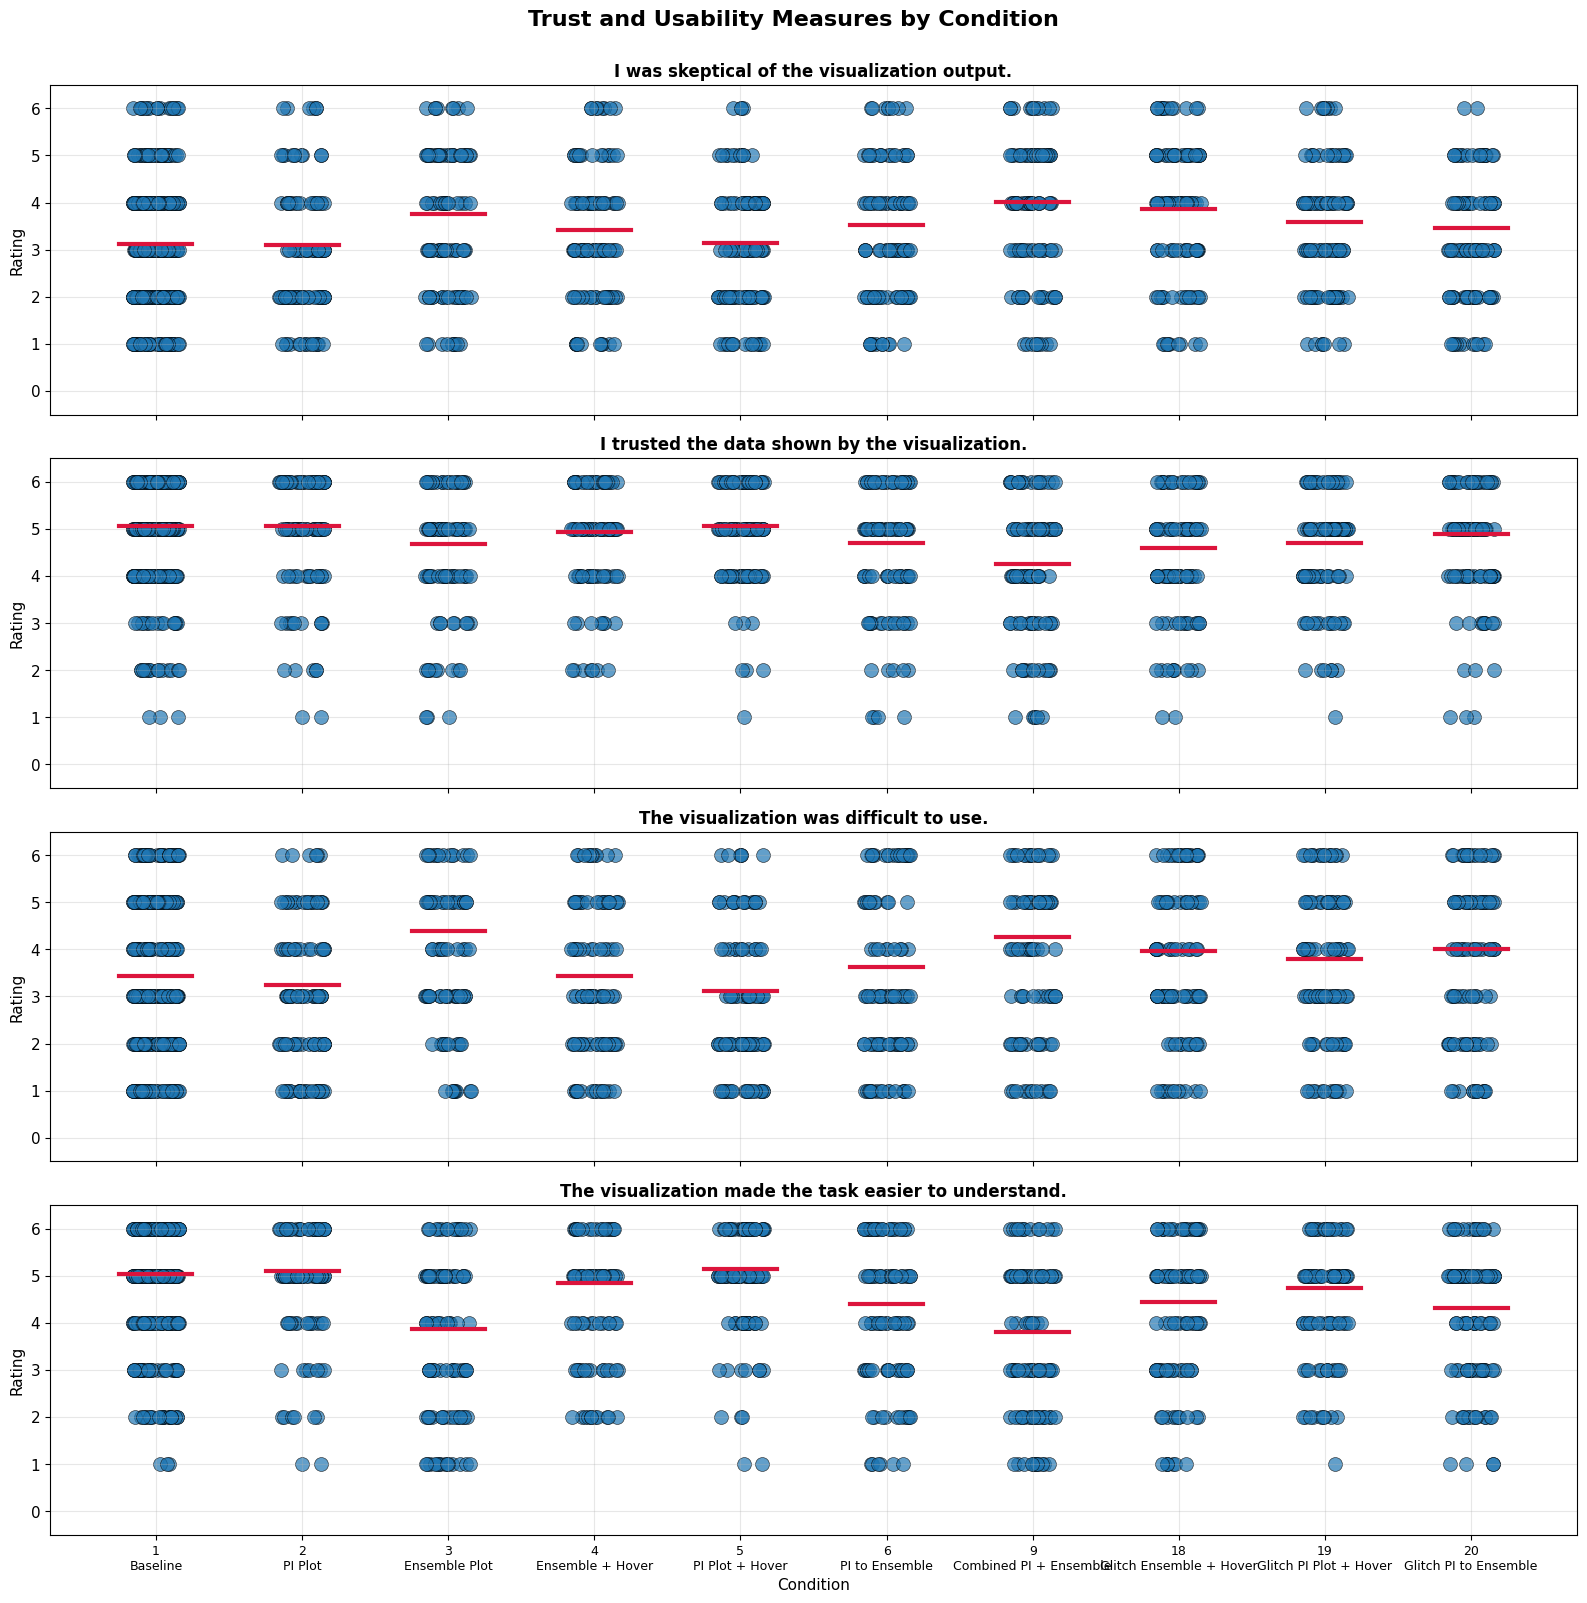

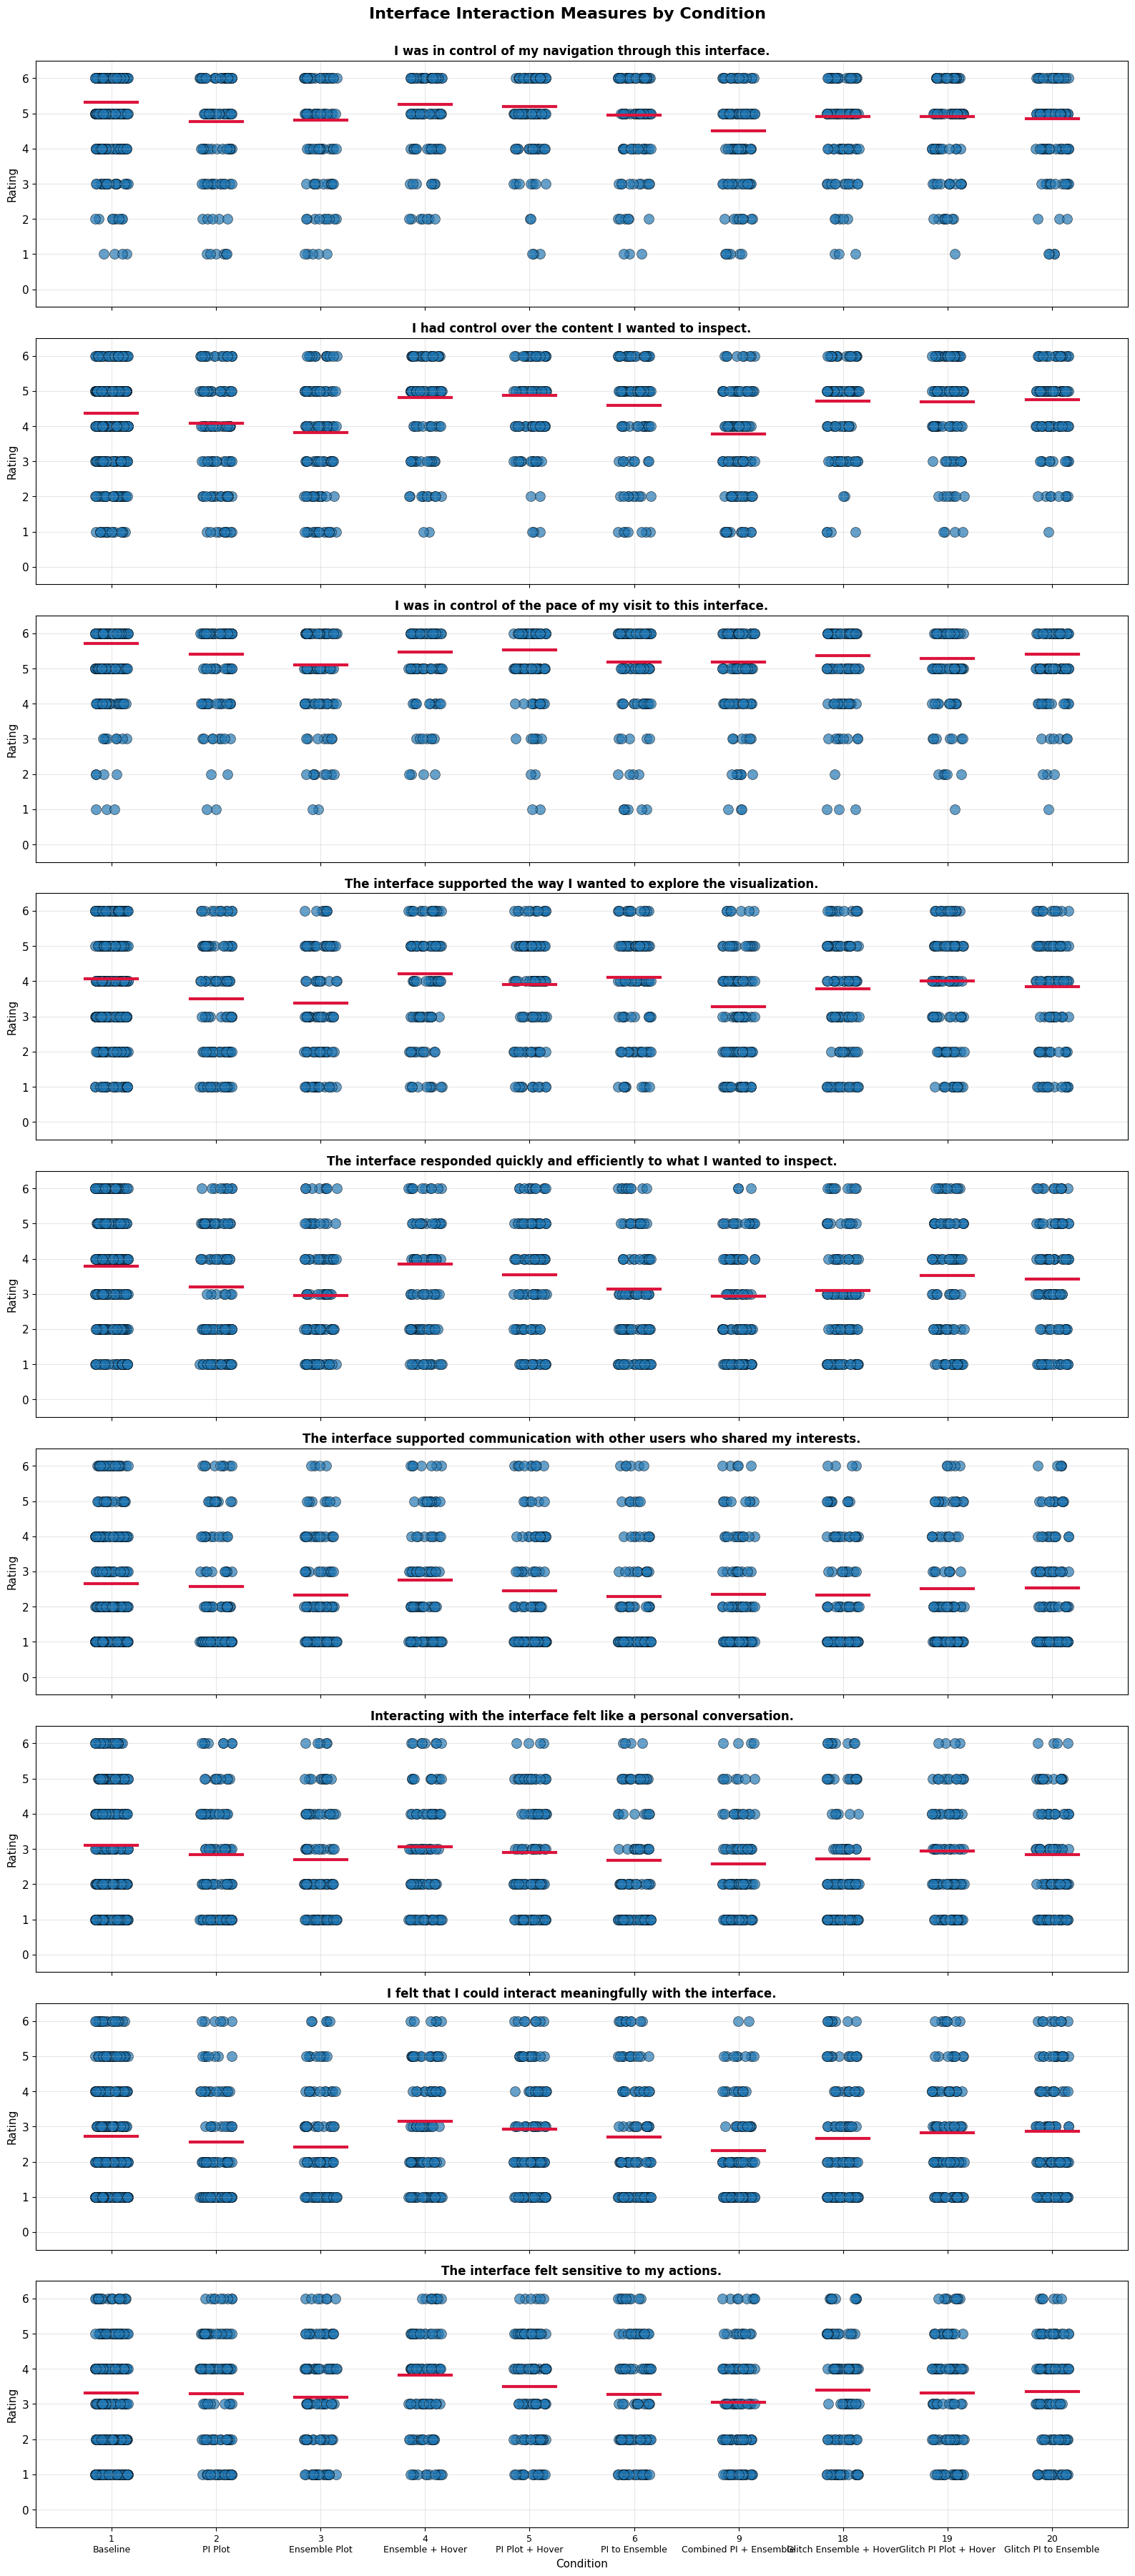

In [112]:
interaction_questions = [
    {"type": "navigation_control", "prompt": "I was in control of my navigation through this interface."},
    {"type": "content_control", "prompt": "I had control over the content I wanted to inspect."},
    {"type": "pace_control", "prompt": "I was in control of the pace of my visit to this interface."},
    {"type": "interface_exploration", "prompt": "The interface supported the way I wanted to explore the visualization."},
    {"type": "interface_responsiveness", "prompt": "The interface responded quickly and efficiently to what I wanted to inspect."},
    {"type": "user_communication", "prompt": "The interface supported communication with other users who shared my interests."},
    {"type": "personal_conversation", "prompt": "Interacting with the interface felt like a personal conversation."},
    {"type": "interface_interaction", "prompt": "I felt that I could interact meaningfully with the interface."},
    {"type": "interface_sensitivity", "prompt": "The interface felt sensitive to my actions."},
]

trust_questions = [
    {"type": "skeptical_rating", "prompt": "I was skeptical of the visualization output."},
    {"type": "data_trust", "prompt": "I trusted the data shown by the visualization."},
    {"type": "usability_difficulty", "prompt": "The visualization was difficult to use."},
    {"type": "comprehension_ease", "prompt": "The visualization made the task easier to understand."},
]


def create_sectioned_survey_plots(data, questions, section_title, exclude_baseline=True):
    if data.empty:
        print(f"No data available for {section_title}")
        return

    condition_frame = (
        data[["condition_number", "condition_name"]]
        .dropna()
        .drop_duplicates()
        .sort_values("condition_number")
    )
    if exclude_baseline:
        condition_frame = condition_frame[condition_frame["condition_number"] != 0]

    position_map = {
        int(row.condition_number): index + 1
        for index, row in enumerate(condition_frame.itertuples(index=False))
    }
    labels = [
        f"{int(row.condition_number)}\n{row.condition_name}"
        for row in condition_frame.itertuples(index=False)
    ]

    fig, axes = plt.subplots(len(questions), 1, figsize=(16, 4 * len(questions)), sharex=True)
    if len(questions) == 1:
        axes = [axes]

    for ax, question in zip(axes, questions):
        key = question["type"]
        plot_rows = data[data[key].notna() & data["condition_number"].notna()].copy()
        if exclude_baseline:
            plot_rows = plot_rows[plot_rows["condition_number"] != 0].copy()

        if plot_rows.empty:
            ax.set_title(question["prompt"], fontsize=12, fontweight="bold")
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center")
            continue

        plot_rows["x_position"] = plot_rows["condition_number"].astype(int).map(position_map)
        np.random.seed(42)
        jitter = np.random.uniform(-0.16, 0.16, len(plot_rows))
        ax.scatter(
            plot_rows["x_position"] + jitter,
            plot_rows[key],
            alpha=0.7,
            s=100,
            edgecolors="black",
            linewidth=0.5,
            color="#1f77b4",
        )

        means = plot_rows.groupby("condition_number")[key].mean()
        for condition_number, mean_value in means.items():
            x_pos = position_map[int(condition_number)]
            ax.plot([x_pos - 0.25, x_pos + 0.25], [mean_value, mean_value], color="crimson", linewidth=3)

        ax.set_title(question["prompt"], fontsize=12, fontweight="bold")
        ax.set_ylabel("Rating")
        ax.set_ylim(-0.5, 6.5)
        ax.grid(True, axis="y", alpha=0.3)

    axes[-1].set_xticks(list(position_map.values()))
    axes[-1].set_xticklabels(labels, fontsize=9)
    axes[-1].set_xlabel("Condition")
    fig.suptitle(section_title, fontsize=16, fontweight="bold", y=1.0)
    plt.tight_layout()
    plt.show()


create_sectioned_survey_plots(
    trust_data,
    trust_questions,
    section_title="Trust and Usability Measures by Condition",
)

create_sectioned_survey_plots(
    interaction_data,
    interaction_questions,
    section_title="Interface Interaction Measures by Condition",
)

## 5. Composite Scores, Interaction Frequency, and Feedback Page

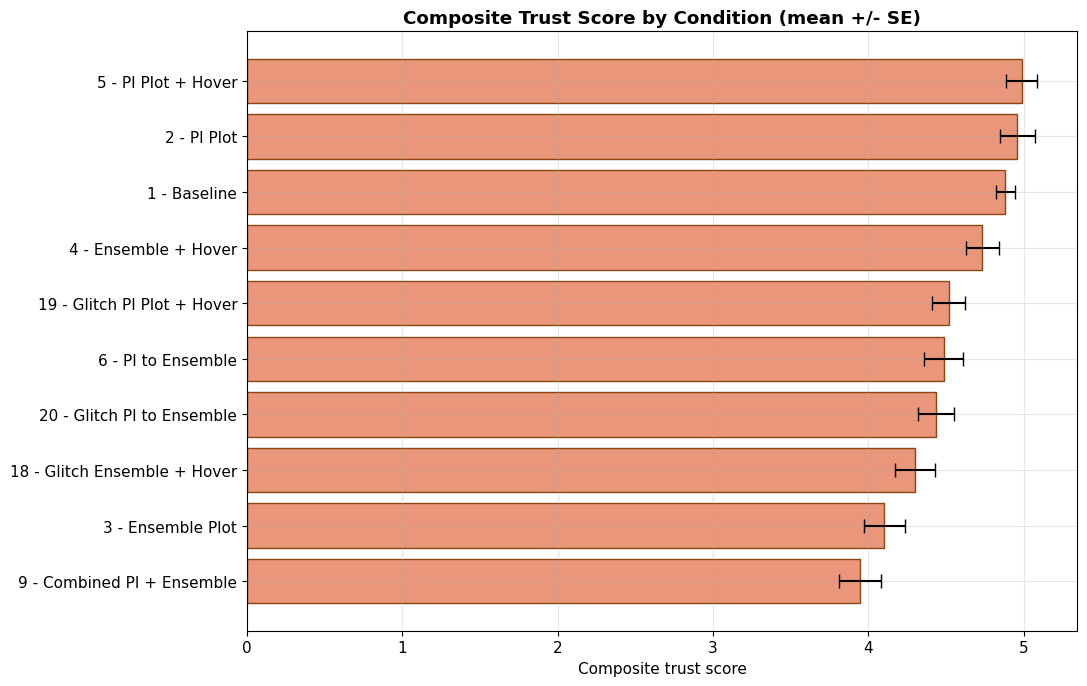

,condition_number,condition_name,mean_score,sd_score,n,se_score
0,5.0,PI Plot + Hover,4.987,1.092,117,0.100955
1,2.0,PI Plot,4.958,1.214,114,0.113702
2,1.0,Baseline,4.882,1.112,335,0.060755
3,4.0,Ensemble + Hover,4.732,1.114,109,0.106702
4,19.0,Glitch PI Plot + Hover,4.516,1.132,109,0.108426
5,6.0,PI to Ensemble,4.484,1.333,109,0.127678
6,20.0,Glitch PI to Ensemble,4.436,1.234,114,0.115575
7,18.0,Glitch Ensemble + Hover,4.299,1.336,112,0.126240
8,3.0,Ensemble Plot,4.103,1.388,109,0.132946
9,9.0,Combined PI + Ensemble,3.946,1.438,112,0.135878


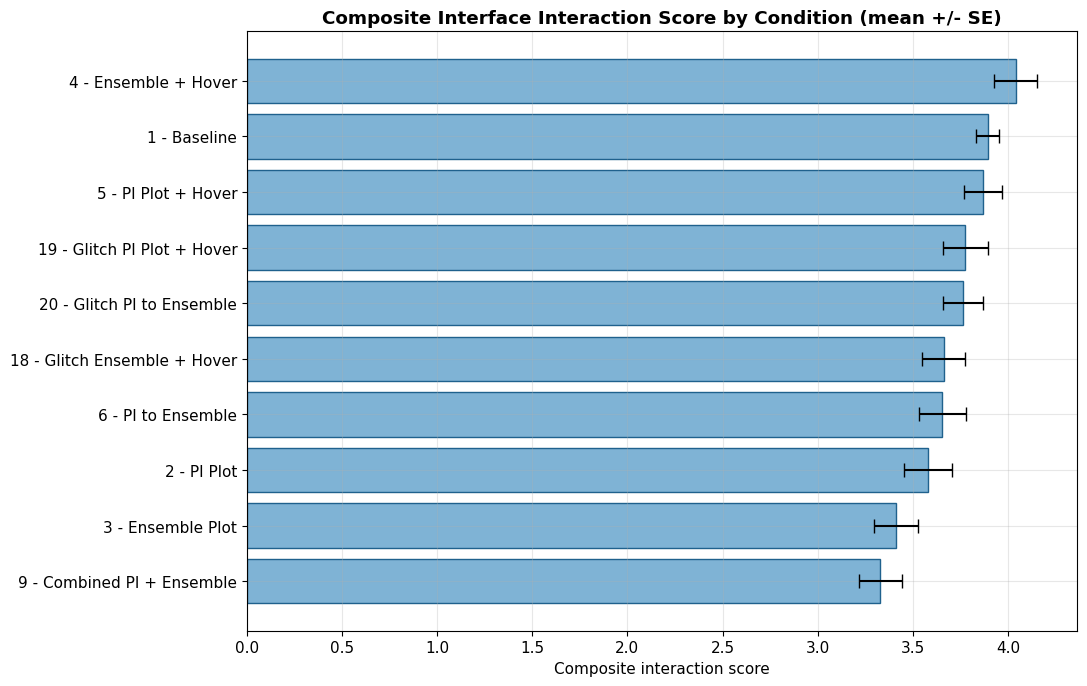

,condition_number,condition_name,mean_score,sd_score,n,se_score
0,4.0,Ensemble + Hover,4.042,1.185,109,0.113502
1,1.0,Baseline,3.893,1.144,335,0.062503
2,5.0,PI Plot + Hover,3.869,1.073,117,0.099199
3,19.0,Glitch PI Plot + Hover,3.775,1.237,109,0.118483
4,20.0,Glitch PI to Ensemble,3.763,1.122,114,0.105085
5,18.0,Glitch Ensemble + Hover,3.664,1.196,112,0.113011
6,6.0,PI to Ensemble,3.656,1.276,109,0.122219
7,2.0,PI Plot,3.580,1.326,114,0.124191
8,3.0,Ensemble Plot,3.410,1.206,109,0.115514
9,9.0,Combined PI + Ensemble,3.329,1.193,112,0.112728


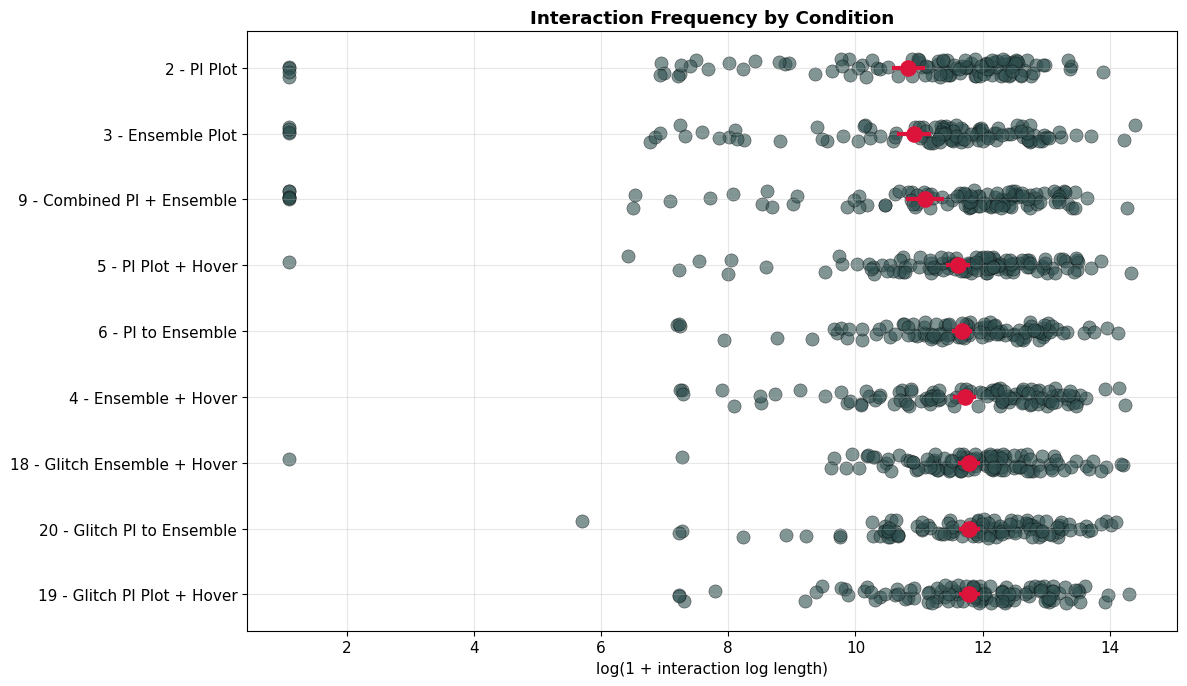

,condition_number,condition_name,mean_freq,sd_freq,n,se_freq
7,19.0,Glitch PI Plot + Hover,11.790,1.373,109,0.131510
8,20.0,Glitch PI to Ensemble,11.787,1.418,114,0.132808
6,18.0,Glitch Ensemble + Hover,11.780,1.491,112,0.140886
2,4.0,Ensemble + Hover,11.716,1.536,109,0.147122
4,6.0,PI to Ensemble,11.677,1.341,109,0.128445
3,5.0,PI Plot + Hover,11.610,1.669,117,0.154299
5,9.0,Combined PI + Ensemble,11.098,2.804,112,0.264953
1,3.0,Ensemble Plot,10.924,2.502,109,0.239648
0,2.0,PI Plot,10.830,2.459,114,0.230306


Feedback page rows: 0
No feedback page rows found.


In [113]:
import html
from IPython.display import HTML


def summarize_composite_scale(data, question_keys, score_column, reverse_columns=None):
    reverse_columns = set(reverse_columns or [])

    valid_data = data[data["condition_number"].notna()].copy()
    valid_data = valid_data[valid_data["condition_number"] != 0].copy()

    for col in question_keys:
        if col in reverse_columns:
            valid_data[f"{col}_scored"] = _reverse_likert_scale_1_7(valid_data[col])
        else:
            valid_data[f"{col}_scored"] = valid_data[col]

    scored_columns = [f"{col}_scored" for col in question_keys]
    valid_data[score_column] = valid_data[scored_columns].mean(axis=1, skipna=True)

    summary = (
        valid_data.groupby(["condition_number", "condition_name"])
        .agg(
            mean_score=(score_column, "mean"),
            sd_score=(score_column, "std"),
            n=(score_column, "count"),
        )
        .round(3)
        .reset_index()
    )
    summary["se_score"] = summary["sd_score"] / np.sqrt(summary["n"])
    return valid_data, summary


def plot_condition_score_summary(summary, value_col, error_col, x_label, title, color, edgecolor):
    if summary.empty:
        print(f"No data available for {title}")
        return

    plot_summary = summary.sort_values(value_col, ascending=False).reset_index(drop=True)

    plt.figure(figsize=(11, 7))
    plt.barh(
        range(len(plot_summary)),
        plot_summary[value_col],
        xerr=plot_summary[error_col],
        color=color,
        edgecolor=edgecolor,
        capsize=5,
    )
    plt.yticks(
        range(len(plot_summary)),
        [
            f"{int(row.condition_number)} - {row.condition_name}"
            for row in plot_summary.itertuples(index=False)
        ],
    )
    plt.gca().invert_yaxis()
    plt.xlabel(x_label)
    plt.title(title, fontweight="bold")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def analyze_composite_trust_score(data):
    trust_columns = [
        "skeptical_rating",
        "data_trust",
        "usability_difficulty",
        "comprehension_ease",
    ]
    reverse_columns = ["skeptical_rating", "usability_difficulty"]

    valid_data, summary = summarize_composite_scale(
        data,
        trust_columns,
        score_column="composite_trust_score",
        reverse_columns=reverse_columns,
    )

    plot_condition_score_summary(
        summary,
        value_col="mean_score",
        error_col="se_score",
        x_label="Composite trust score",
        title="Composite Trust Score by Condition (mean +/- SE)",
        color="#E9967A",
        edgecolor="#8B4513",
    )

    display(summary.sort_values("mean_score", ascending=False).reset_index(drop=True))
    return valid_data, summary


def analyze_composite_interaction_score(data):
    valid_data, summary = summarize_composite_scale(
        data,
        INTERACTION_QUESTION_KEYS,
        score_column="composite_interaction_score",
    )

    plot_condition_score_summary(
        summary,
        value_col="mean_score",
        error_col="se_score",
        x_label="Composite interaction score",
        title="Composite Interface Interaction Score by Condition (mean +/- SE)",
        color="#7FB3D5",
        edgecolor="#1F618D",
    )

    display(summary.sort_values("mean_score", ascending=False).reset_index(drop=True))
    return valid_data, summary


def create_interaction_freq_dot_plot(data):
    valid_data = data[data["condition_number"].notna()].copy()
    valid_data = valid_data[valid_data["condition_number"] != 0].copy()

    summary = (
        valid_data.groupby(["condition_number", "condition_name"])
        .agg(
            mean_freq=("interaction_freq", "mean"),
            sd_freq=("interaction_freq", "std"),
            n=("interaction_freq", "count"),
        )
        .round(3)
        .reset_index()
        .sort_values("mean_freq", ascending=False)
    )
    summary["se_freq"] = summary["sd_freq"] / np.sqrt(summary["n"])

    label_order = [row.condition_name for row in summary.itertuples(index=False)]
    y_map = {label: index for index, label in enumerate(label_order)}

    plt.figure(figsize=(12, 7))
    np.random.seed(42)
    for _, row in valid_data.iterrows():
        y_pos = y_map[row["condition_name"]] + np.random.uniform(-0.14, 0.14)
        plt.scatter(
            row["interaction_freq"],
            y_pos,
            alpha=0.6,
            s=90,
            color="#2F4F4F",
            edgecolors="black",
            linewidth=0.4,
        )

    for _, row in summary.iterrows():
        y_pos = y_map[row["condition_name"]]
        plt.plot(
            [row["mean_freq"] - row["se_freq"], row["mean_freq"] + row["se_freq"]],
            [y_pos, y_pos],
            color="crimson",
            linewidth=3,
        )
        plt.scatter(row["mean_freq"], y_pos, color="crimson", s=120, zorder=3)

    plt.yticks(
        range(len(label_order)),
        [
            f"{int(row.condition_number)} - {row.condition_name}"
            for row in summary.itertuples(index=False)
        ],
    )
    plt.xlabel("log(1 + interaction log length)")
    plt.title("Interaction Frequency by Condition", fontweight="bold")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    display(summary)
    return summary


def normalize_yes_no(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    if text in {"yes", "y", "true", "1"}:
        return "Yes"
    if text in {"no", "n", "false", "0"}:
        return "No"
    return np.nan


def prepare_feedback_page_data(data):
    feedback_rows = data[
        (data["trial_type"] == "interaction-feedback")
        & (data["phase"].isin([2, 3, 4]))
        & data["condition_number"].notna()
    ].copy()
    feedback_rows = feedback_rows[feedback_rows["condition_number"] != 0].copy()

    parsed_feedback = feedback_rows["response"].apply(parse_response_json).apply(pd.Series)
    feedback_rows = pd.concat(
        [feedback_rows.reset_index(drop=True), parsed_feedback.reset_index(drop=True)],
        axis=1,
    )

    for col in ["encounter_bug", "annoying_design"]:
        if col in feedback_rows.columns:
            feedback_rows[col] = feedback_rows[col].apply(normalize_yes_no)

    for col in ["bug_elaboration", "annoying_elaboration"]:
        if col in feedback_rows.columns:
            feedback_rows[col] = feedback_rows[col].fillna("").astype(str).str.strip()

    return feedback_rows.sort_values(["condition_number", "participant_id"]).reset_index(drop=True)


def create_feedback_ratio_stacked_bar(
    feedback_data,
    response_col,
    title,
    no_label,
    yes_label,
    no_color,
    yes_color,
):
    plot_rows = feedback_data[feedback_data[response_col].notna()].copy()
    if plot_rows.empty:
        print(f"No data available for {title}")
        return pd.DataFrame()

    summary = (
        plot_rows.groupby(["condition_number", "condition_name", response_col])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["No", "Yes"], fill_value=0)
        .reset_index()
        .sort_values("condition_number")
    )
    summary["total"] = summary["No"] + summary["Yes"]
    summary["no_ratio"] = np.where(summary["total"] > 0, summary["No"] / summary["total"], 0)
    summary["yes_ratio"] = np.where(summary["total"] > 0, summary["Yes"] / summary["total"], 0)

    y_pos = np.arange(len(summary))
    labels = [
        f"{int(row.condition_number)} - {row.condition_name}"
        for row in summary.itertuples(index=False)
    ]

    plt.figure(figsize=(12, 6))
    plt.barh(y_pos, summary["no_ratio"], color=no_color, edgecolor="white", label=no_label)
    plt.barh(
        y_pos,
        summary["yes_ratio"],
        left=summary["no_ratio"],
        color=yes_color,
        edgecolor="white",
        label=yes_label,
    )

    for idx, row in summary.iterrows():
        if row["no_ratio"] > 0.05:
            plt.text(
                row["no_ratio"] / 2,
                idx,
                f"{row['no_ratio']:.0%}",
                ha="center",
                va="center",
                color="black",
                fontsize=9,
            )
        if row["yes_ratio"] > 0.05:
            plt.text(
                row["no_ratio"] + row["yes_ratio"] / 2,
                idx,
                f"{row['yes_ratio']:.0%}",
                ha="center",
                va="center",
                color="white",
                fontsize=9,
                fontweight="bold",
            )

    plt.yticks(y_pos, labels)
    plt.xlim(0, 1)
    plt.xlabel("Ratio")
    plt.ylabel("Condition")
    plt.title(title, fontweight="bold")
    plt.legend(loc="lower right")
    plt.grid(True, axis="x", alpha=0.3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    display(
        summary[
            [
                "condition_number",
                "condition_name",
                "No",
                "Yes",
                "no_ratio",
                "yes_ratio",
            ]
        ].rename(
            columns={
                "No": no_label,
                "Yes": yes_label,
                "no_ratio": f"{no_label} ratio",
                "yes_ratio": f"{yes_label} ratio",
            }
        )
    )
    return summary


def display_feedback_text_boxes(feedback_data, text_col, section_title):
    condition_rows = (
        feedback_data[["condition_number", "condition_name"]]
        .drop_duplicates()
        .sort_values("condition_number")
    )

    print(section_title)
    for row in condition_rows.itertuples(index=False):
        subset = feedback_data[
            (feedback_data["condition_number"] == row.condition_number)
            & feedback_data[text_col].ne("")
        ].copy()

        if subset.empty:
            content = "[no feedback submitted]"
        else:
            content = "\n".join(
                f"{participant_id}: {feedback}"
                for participant_id, feedback in subset[["participant_id", text_col]].itertuples(index=False)
            )

        box_html = f"""
        <div style=\"margin: 12px 0 20px 0;\">
            <div style=\"font-weight: 600; margin-bottom: 6px;\">{int(row.condition_number)} - {html.escape(str(row.condition_name))}</div>
            <div style=\"border: 1px solid #c9cdd3; border-radius: 8px; background: #f8f9fb; padding: 12px; white-space: pre-wrap; font-family: monospace; font-size: 12px; line-height: 1.5;\">{html.escape(content)}</div>
        </div>
        """
        display(HTML(box_html))


def analyze_feedback_page(data):
    feedback_data = prepare_feedback_page_data(data)
    print(f"Feedback page rows: {len(feedback_data)}")

    if feedback_data.empty:
        print("No feedback page rows found.")
        return feedback_data, pd.DataFrame(), pd.DataFrame()

    bug_ratio_summary = create_feedback_ratio_stacked_bar(
        feedback_data,
        response_col="encounter_bug",
        title="Feedback Page: Bug Encounter Ratio by Condition",
        no_label="No bug",
        yes_label="Bug reported",
        no_color="#CFE8CF",
        yes_color="#D95F5F",
    )

    bad_interaction_ratio_summary = create_feedback_ratio_stacked_bar(
        feedback_data,
        response_col="annoying_design",
        title="Feedback Page: Bad Interaction Ratio by Condition",
        no_label="Not bad interaction",
        yes_label="Bad interaction reported",
        no_color="#D6EAF8",
        yes_color="#5DADE2",
    )

    display_feedback_text_boxes(
        feedback_data,
        text_col="bug_elaboration",
        section_title="Feedback text box responses: bug elaboration",
    )
    display_feedback_text_boxes(
        feedback_data,
        text_col="annoying_elaboration",
        section_title="Feedback text box responses: bad interaction elaboration",
    )

    return feedback_data, bug_ratio_summary, bad_interaction_ratio_summary


composite_trust_data, composite_trust_summary = analyze_composite_trust_score(trust_data)
composite_interaction_data, composite_interaction_summary = analyze_composite_interaction_score(interaction_data)
interaction_freq_summary = create_interaction_freq_dot_plot(phase2_data)
feedback_page_data, feedback_bug_ratio_summary, feedback_bad_interaction_ratio_summary = analyze_feedback_page(combined_data)


## 5.1 Factor Analysis of Trust vs Interaction Questions



=== Trust Questions ===
Number of complete rows used: 1340
Variables tested: 4
Kaiser eigenvalues > 1: 1, using 1 factor(s)


,Factor 1,max_abs
question_prompt,,
The visualization was difficult to use.,1.453553,1.453553
The visualization made the task easier to understand.,-1.337549,1.337549
I trusted the data shown by the visualization.,-0.856877,0.856877
I was skeptical of the visualization output.,0.851150,0.851150


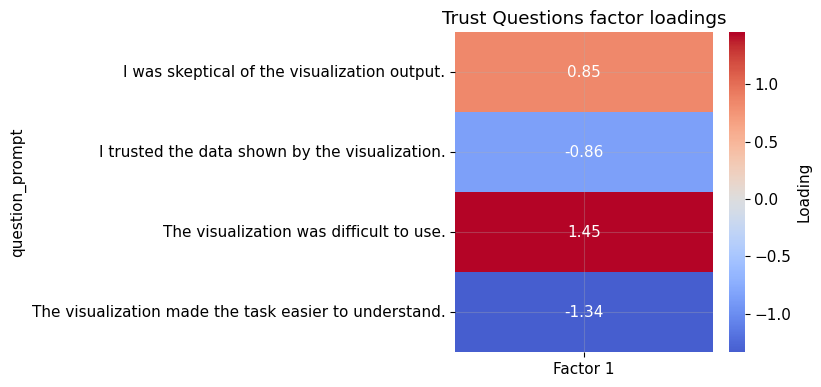


=== Interaction Questions ===
Number of complete rows used: 1340
Variables tested: 9
Kaiser eigenvalues > 1: 2, using 2 factor(s)


,Factor 1,Factor 2,max_abs
question_prompt,,,
Interacting with the interface felt like a personal conversation.,1.531042,0.327202,1.531042
I felt that I could interact meaningfully with the interface.,1.454183,0.328560,1.454183
The interface responded quickly and efficiently to what I wanted to inspect.,1.427821,-0.066530,1.427821
The interface supported communication with other users who shared my interests.,1.362813,0.447699,1.362813
The interface supported the way I wanted to explore the visualization.,1.258364,-0.311588,1.258364
The interface felt sensitive to my actions.,1.193468,-0.016626,1.193468
I was in control of my navigation through this interface.,0.674272,-0.954071,0.954071
I was in control of the pace of my visit to this interface.,0.364369,-0.922508,0.922508
I had control over the content I wanted to inspect.,0.912934,-0.755126,0.912934


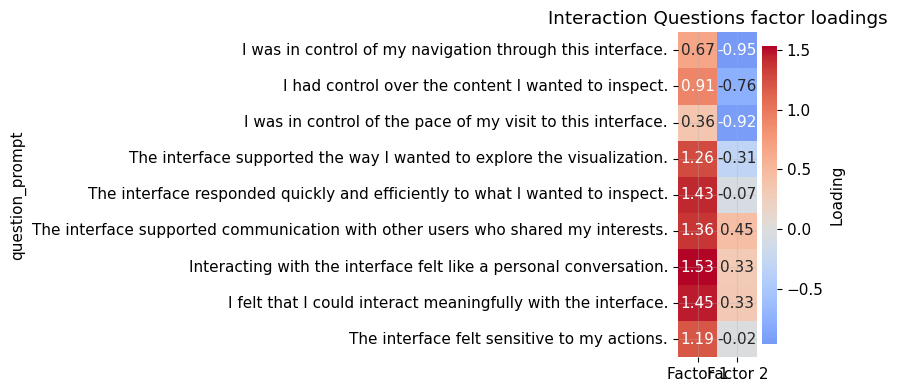

In [114]:
# Factor analysis on survey dimensions (trust vs interaction), performed separately.

import warnings

import numpy as np

from sklearn.decomposition import FactorAnalysis



def _resolve_data_and_keys():
    trust_df = globals().get("analysis_trust_data", globals().get("trust_data"))
    interaction_df = globals().get("analysis_interaction_data", globals().get("interaction_data"))
    trust_keys = globals().get("TRUST_QUESTION_KEYS", [])
    interaction_keys = globals().get(
        "COMBINED_INTERACTION_QUESTION_KEYS",
        globals().get("INTERACTION_QUESTION_KEYS", []),
    )

    return trust_df, interaction_df, trust_keys, interaction_keys


def _label_map(question_keys, prompt_cells):
    if not question_keys:
        return {}

    prompt_list = globals().get(prompt_cells)
    if not isinstance(prompt_list, list):
        return {}

    mapping = {}
    for item in prompt_list:
        if not isinstance(item, dict):
            continue
        key = item.get("type")
        if key in question_keys:
            mapping[key] = item.get("prompt", key)
    return mapping


def run_factor_analysis(data, question_keys, section_label, prompt_cells=None):
    """Run a quick exploratory factor analysis on a survey question block."""

    if data is None or data.empty:
        print(f"[skip] {section_label}: no rows available.")
        return {}

    if not question_keys:
        print(f"[skip] {section_label}: no question keys configured.")
        return {}

    available_keys = [k for k in question_keys if k in data.columns]
    if len(available_keys) < 2:
        print(f"[skip] {section_label}: fewer than 2 available question columns ({len(available_keys)}).")
        return {}

    analysis_rows = data.copy()
    if "condition_number" in analysis_rows.columns:
        analysis_rows = analysis_rows[analysis_rows["condition_number"] != 0].copy()

    analysis_rows = analysis_rows[[c for c in available_keys if c in analysis_rows.columns]].copy()
    analysis_rows = analysis_rows.apply(pd.to_numeric, errors="coerce").dropna()

    if analysis_rows.shape[0] < 10 or analysis_rows.shape[1] < 2:
        print(
            f"[skip] {section_label}: not enough complete rows/columns for factor analysis "
            f"(n={analysis_rows.shape[0]}, p={analysis_rows.shape[1]})."
        )
        return {}

    constant_columns = [col for col in analysis_rows.columns if analysis_rows[col].nunique(dropna=True) <= 1]
    if constant_columns:
        analysis_rows = analysis_rows.drop(columns=constant_columns)
        print(
            f"[note] {section_label}: dropped constant columns "
            f"({', '.join(constant_columns)})."
        )

    if analysis_rows.shape[1] < 2:
        print(f"[skip] {section_label}: too few non-constant columns after cleanup ({analysis_rows.shape[1]}).")
        return {}

    corr = analysis_rows.corr().to_numpy()
    with np.errstate(invalid="ignore", divide="ignore"):
        eigvals = np.linalg.eigvalsh(corr)
    eigvals = np.sort(np.real(eigvals))[::-1]

    if analysis_rows.shape[0] <= 1:
        print(f"[skip] {section_label}: not enough rows after cleaning.")
        return {}

    n_factors = int((eigvals > 1.0).sum())
    n_factors = max(1, min(n_factors, analysis_rows.shape[1], analysis_rows.shape[0] - 1))

    if n_factors <= 0:
        n_factors = 1

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        fa = FactorAnalysis(n_components=n_factors, random_state=42)
        factor_scores = fa.fit_transform(analysis_rows)

    loading_matrix = pd.DataFrame(
        fa.components_.T,
        index=analysis_rows.columns,
        columns=[f"Factor {i + 1}" for i in range(n_factors)],
    )

    label_map = _label_map(available_keys, prompt_cells or "")
    if label_map:
        loading_matrix = loading_matrix.copy()
        loading_matrix["question_prompt"] = [
            label_map.get(index, index) for index in loading_matrix.index
        ]
        loading_matrix = loading_matrix.set_index("question_prompt")

    loading_matrix["max_abs"] = loading_matrix[[f"Factor {i + 1}" for i in range(n_factors)]].abs().max(
        axis=1
    )

    print(f"\n=== {section_label} ===")
    print(f"Number of complete rows used: {len(analysis_rows)}")
    print(f"Variables tested: {analysis_rows.shape[1]}")
    print(f"Kaiser eigenvalues > 1: {int((eigvals > 1).sum())}, "
          f"using {n_factors} factor(s)")

    display(loading_matrix.sort_values("max_abs", ascending=False))

    plt.figure(figsize=(max(8, 2 * n_factors + 3), max(4, len(analysis_rows.columns) * 0.45)))
    sns.heatmap(
        loading_matrix[[f"Factor {i + 1}" for i in range(n_factors)]],
        annot=True,
        cmap="coolwarm",
        center=0,
        fmt=".2f",
        cbar_kws={"label": "Loading"},
    )
    plt.title(f"{section_label} factor loadings")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return {
        "n_factors": n_factors,
        "eigenvalues": eigvals,
        "loadings": loading_matrix.drop(columns="max_abs"),
        "factor_scores": pd.DataFrame(
            factor_scores,
            columns=[f"Factor {i + 1}" for i in range(n_factors)],
        ),
        "analysis_data": analysis_rows,
    }


trust_df, interaction_df, trust_keys, interaction_keys = _resolve_data_and_keys()

trust_factor_results = run_factor_analysis(
    trust_df,
    trust_keys,
    section_label="Trust Questions",
    prompt_cells="trust_questions",
)

interaction_factor_results = run_factor_analysis(
    interaction_df,
    interaction_keys,
    section_label="Interaction Questions",
    prompt_cells="interaction_questions",
)

factor_analysis_summary = {
    "trust": trust_factor_results,
    "interaction": interaction_factor_results,
}



## 5.2 Factor-Aligned Comparison: Trust, Control, Interface


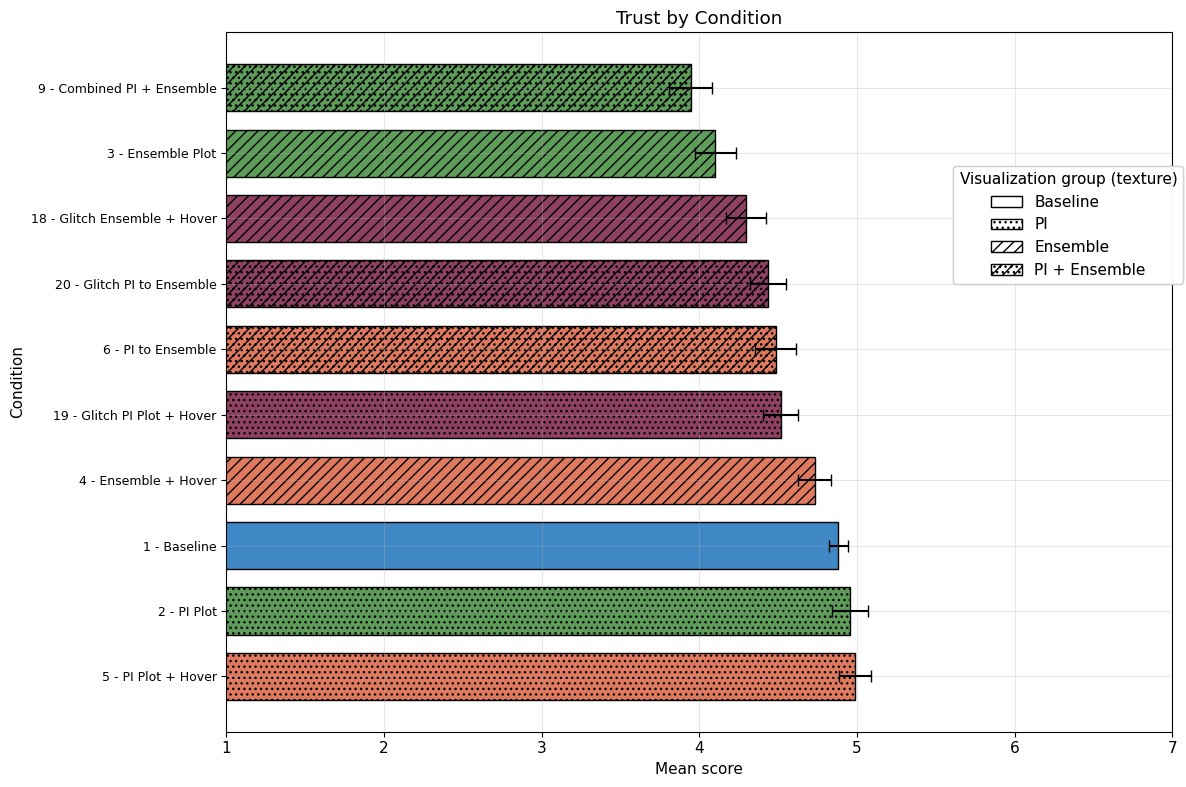

,condition_number,condition_name,mean_score,sd_score,se_score,n,interaction_group,visualization_group
0,5,PI Plot + Hover,4.987,1.092,0.100955,117,Interactive,PI
1,2,PI Plot,4.958,1.214,0.113702,114,Static,PI
2,1,Baseline,4.882,1.112,0.060755,335,Baseline,Baseline
3,4,Ensemble + Hover,4.732,1.114,0.106702,109,Interactive,Ensemble
4,19,Glitch PI Plot + Hover,4.516,1.132,0.108426,109,Glitch,PI
5,6,PI to Ensemble,4.484,1.333,0.127678,109,Interactive,PI + Ensemble
6,20,Glitch PI to Ensemble,4.436,1.234,0.115575,114,Glitch,PI + Ensemble
7,18,Glitch Ensemble + Hover,4.299,1.336,0.126240,112,Glitch,Ensemble
8,3,Ensemble Plot,4.103,1.388,0.132946,109,Static,Ensemble
9,9,Combined PI + Ensemble,3.946,1.438,0.135878,112,Static,PI + Ensemble


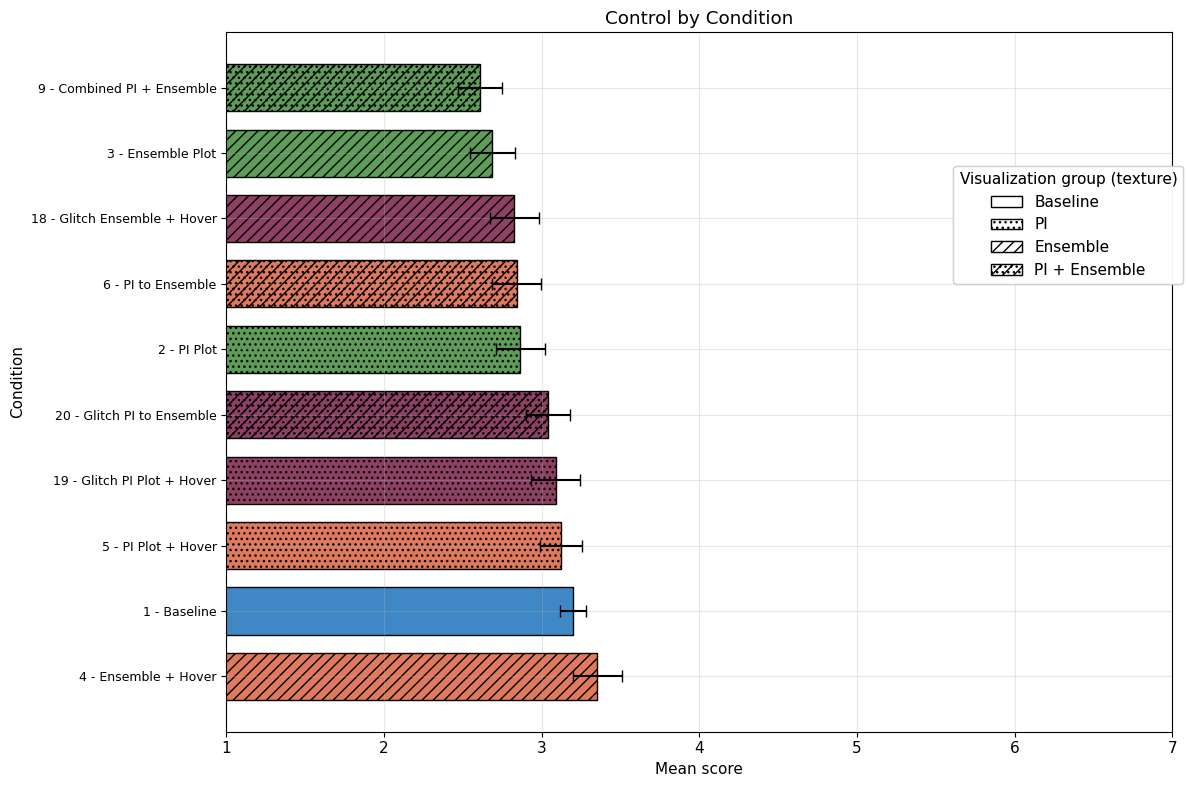

,condition_number,condition_name,mean_score,sd_score,se_score,n,interaction_group,visualization_group
0,4,Ensemble + Hover,3.352,1.622,0.155359,109,Interactive,Ensemble
1,1,Baseline,3.202,1.517,0.082883,335,Baseline,Baseline
2,5,PI Plot + Hover,3.123,1.458,0.134792,117,Interactive,PI
3,19,Glitch PI Plot + Hover,3.089,1.642,0.157275,109,Glitch,PI
4,20,Glitch PI to Ensemble,3.041,1.507,0.141143,114,Glitch,PI + Ensemble
5,2,PI Plot,2.865,1.675,0.156878,114,Static,PI
6,6,PI to Ensemble,2.841,1.640,0.157084,109,Interactive,PI + Ensemble
7,18,Glitch Ensemble + Hover,2.827,1.631,0.154115,112,Glitch,Ensemble
8,3,Ensemble Plot,2.688,1.489,0.142620,109,Static,Ensemble
9,9,Combined PI + Ensemble,2.610,1.473,0.139185,112,Static,PI + Ensemble


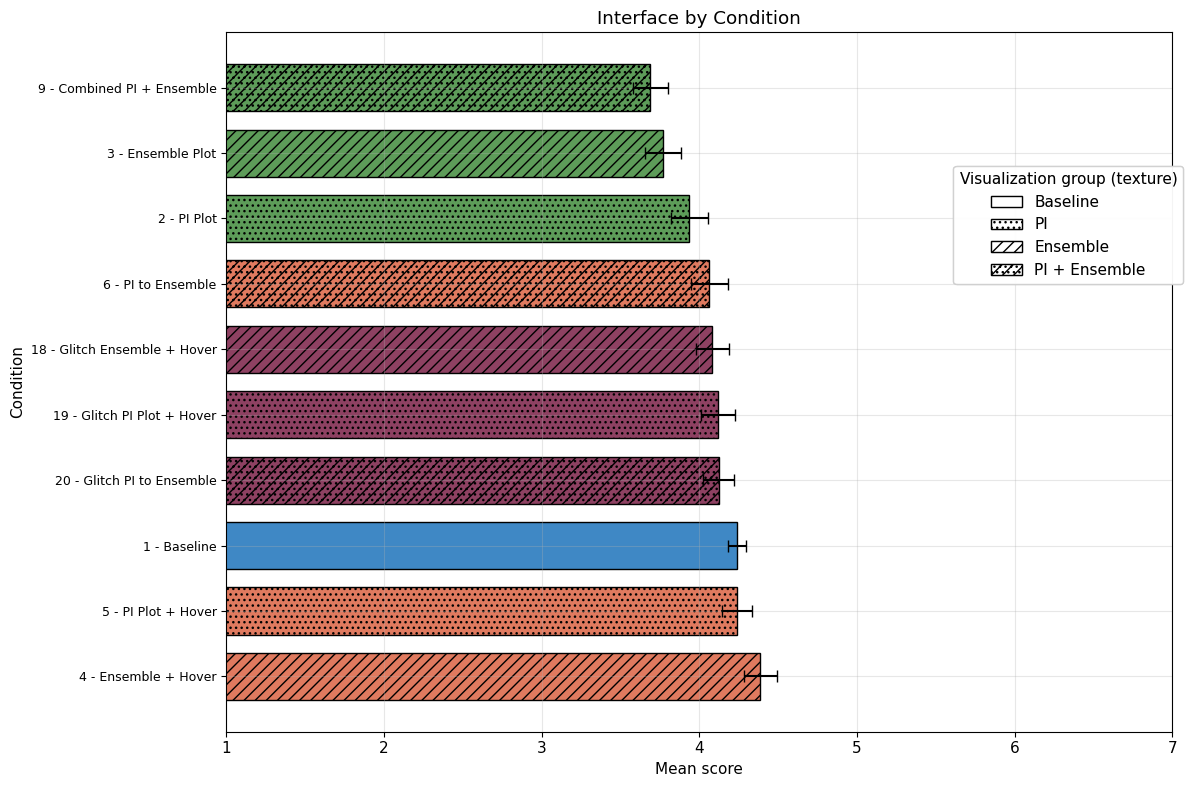

,condition_number,condition_name,mean_score,sd_score,se_score,n,interaction_group,visualization_group
0,4,Ensemble + Hover,4.387,1.095,0.104882,109,Interactive,Ensemble
1,5,PI Plot + Hover,4.242,1.024,0.094669,117,Interactive,PI
2,1,Baseline,4.238,1.056,0.057695,335,Baseline,Baseline
3,20,Glitch PI to Ensemble,4.124,1.035,0.096937,114,Glitch,PI + Ensemble
4,19,Glitch PI Plot + Hover,4.118,1.144,0.109575,109,Glitch,PI
5,18,Glitch Ensemble + Hover,4.082,1.114,0.105263,112,Glitch,Ensemble
6,6,PI to Ensemble,4.064,1.229,0.117717,109,Interactive,PI + Ensemble
7,2,PI Plot,3.937,1.243,0.116418,114,Static,PI
8,3,Ensemble Plot,3.771,1.173,0.112353,109,Static,Ensemble
9,9,Combined PI + Ensemble,3.689,1.177,0.111216,112,Static,PI + Ensemble


In [115]:
# 5.2 Factor-aligned comparison metrics by condition

import matplotlib.patches as mpatches


def _to_int_condition(value):
    if pd.isna(value):
        return np.nan
    try:
        return int(float(value))
    except (TypeError, ValueError):
        return np.nan


def _coerce_columns(data, columns):
    return [col for col in columns if col in data.columns]


def _resolve_trust_and_interaction_data():
    trust_source = globals().get("analysis_trust_data", globals().get("trust_data", pd.DataFrame()))
    interaction_source = globals().get(
        "analysis_interaction_data", globals().get("interaction_data", pd.DataFrame())
    )
    return trust_source, interaction_source


TRUST_METRIC_SPEC = [
    ("skeptical_rating", True),
    ("data_trust", False),
    ("usability_difficulty", True),
    ("comprehension_ease", False),
]

CONTROL_ITEM_KEYS = [
    "interface_interaction",
    "personal_conversation",
    "interface_responsiveness",
]

INTERFACE_ITEM_KEYS = [
    "interface_exploration",
    "navigation_control",
    "content_control",
    "pace_control",
    "interface_sensitivity",
]

COMMUNICATION_ITEM_KEYS = [
    "user_communication",
    "peer_communication",
    "customer_communication",
    "company_communication",
]

VISUALIZATION_GROUP_MAP_DEFAULT = {
    "Baseline": [1],
    "PI": [2, 5, 19],
    "Ensemble": [3, 4, 18],
    "PI + Ensemble": [6, 9, 20],
}

INTERACTION_GROUP_MAP_DEFAULT = {
    "Baseline": [1],
    "Static": [2, 3, 9],
    "Interactive": [4, 5, 6],
    "Glitch": [18, 19, 20],
}

VISUALIZATION_GROUP_ORDER = ["Baseline", "PI", "Ensemble", "PI + Ensemble", "Other"]
INTERACTION_GROUP_ORDER = ["Baseline", "Static", "Interactive", "Glitch", "Other"]

INTERACTION_GROUP_COLOR = {
    "Baseline": "#3F88C5",
    "Static": "#5D9C59",
    "Interactive": "#E07A5F",
    "Glitch": "#8E4162",
    "Other": "#888888",
}

VISUALIZATION_GROUP_HATCH = {
    "Baseline": "",
    "PI": "...",
    "Ensemble": "///",
    "PI + Ensemble": "...///",
    "Other": "",
}


def _build_metric_spec_items(interaction_data, include_control=True):
    keys = []
    if include_control:
        for key in CONTROL_ITEM_KEYS:
            if key in interaction_data.columns:
                keys.append((key, False))

    interface_keys = []
    for key in INTERFACE_ITEM_KEYS:
        if key in interaction_data.columns:
            interface_keys.append(key)

    for key in COMMUNICATION_ITEM_KEYS:
        if key in interaction_data.columns:
            interface_keys.append(key)
            break

    if interaction_data is None or interaction_data.empty:
        return [tuple(item) for item in keys], []

    return (
        [tuple(item) for item in keys],
        [(key, False) for key in interface_keys],
    )


def _compute_composite_metric(data, metric_name, metric_spec):
    if data is None or data.empty:
        print(f"[skip] {metric_name}: no data available")
        return pd.DataFrame()

    if "condition_number" not in data.columns or "condition_name" not in data.columns:
        print(f"[skip] {metric_name}: condition fields missing")
        return pd.DataFrame()

    components = []
    for key, reverse in metric_spec:
        if key not in data.columns:
            continue
        numeric = pd.to_numeric(data[key], errors="coerce")
        components.append((_reverse_likert_scale_1_7(numeric) if reverse else numeric).rename(key))

    if not components:
        print(f"[skip] {metric_name}: no metric columns found")
        return pd.DataFrame()

    working = pd.DataFrame(index=data.index)
    working["condition_number"] = data["condition_number"].apply(_to_int_condition)
    working["condition_name"] = data["condition_name"]

    metric_frame = pd.concat(components, axis=1)
    working[metric_name] = metric_frame.mean(axis=1, skipna=True)

    working = working[working["condition_number"].notna()].copy()
    working = working[working["condition_name"].notna()].copy()
    working = working[working[metric_name].notna()].copy()
    if working.empty:
        print(f"[skip] {metric_name}: no complete rows after cleaning")
        return working

    summary = (
        working.groupby(["condition_number", "condition_name"], dropna=False)[metric_name]
        .agg(n="count", mean_score="mean", sd_score="std")
        .reset_index()
        .round(3)
    )

    summary = summary.sort_values(["condition_number", "condition_name"]).reset_index(drop=True)
    summary["se_score"] = summary["sd_score"] / np.sqrt(summary["n"])

    # Attach condition-level style classes
    summary["condition_number"] = summary["condition_number"].astype(int)
    summary["interaction_group"] = summary.apply(
        lambda row: _map_interaction_group(int(row["condition_number"]), row["condition_name"]),
        axis=1,
    )
    summary["visualization_group"] = summary.apply(
        lambda row: _map_visualization_group(int(row["condition_number"]), row["condition_name"]),
        axis=1,
    )

    summary["condition_label"] = summary.apply(
        lambda row: f"{int(row['condition_number'])} - {row['condition_name']}", axis=1
    )

    return summary


def _map_interaction_group(condition_number, condition_name):
    for group_name, conditions in INTERACTION_GROUP_MAP_DEFAULT.items():
        if int(condition_number) in conditions:
            return group_name

    text = str(condition_name).strip().lower()
    if "glitch" in text:
        return "Glitch"
    if "interactive" in text or "interaction" in text:
        return "Interactive"
    if "static" in text:
        return "Static"
    if "baseline" in text:
        return "Baseline"

    return "Other"


def _map_visualization_group(condition_number, condition_name):
    for group_name, conditions in VISUALIZATION_GROUP_MAP_DEFAULT.items():
        if int(condition_number) in conditions:
            return group_name

    text = str(condition_name).strip().lower()
    if "pi" in text and "ensemble" in text:
        return "PI + Ensemble"
    if "ensemble" in text:
        return "Ensemble"
    if "pi" in text:
        return "PI"
    if "baseline" in text:
        return "Baseline"
    return "Other"


def plot_metric_barcharts(metrics):
    if not metrics:
        print("No metric summaries available for plotting")
        return

    for metric_name, summary in metrics.items():
        if summary.empty:
            print(f"No data for {metric_name}")
            continue

        plot_df = (
            summary.assign(
                metric_rank=summary["mean_score"].rank(ascending=False, method="dense").astype(int)
            )
            .sort_values(["metric_rank", "condition_name"])
            .reset_index(drop=True)
            .copy()
        )

        y = np.arange(len(plot_df))
        height = max(8, len(plot_df) * 0.45)
        plt.figure(figsize=(12, height))

        for idx, row in plot_df.iterrows():
            interaction_group = row["interaction_group"]
            visualization_group = row["visualization_group"]
            color = INTERACTION_GROUP_COLOR.get(interaction_group, INTERACTION_GROUP_COLOR["Other"])
            hatch = VISUALIZATION_GROUP_HATCH.get(
                visualization_group,
                VISUALIZATION_GROUP_HATCH["Other"],
            )

            plt.barh(
                y[idx],
                row["mean_score"],
                xerr=row["se_score"],
                color=color,
                edgecolor="black",
                hatch=hatch,
                height=0.72,
                capsize=4,
            )

        plt.yticks(y, plot_df["condition_label"], fontsize=9)
        plt.ylabel("Condition")
        plt.xlabel("Mean score")
        plt.title(f"{metric_name} by Condition")
        plt.xlim(1, 7)
        plt.xticks(range(1, 8))
        plt.grid(axis="x", alpha=0.3)
        plt.tight_layout()

        # Style legends: color (interaction availability) and hatch (visualization type)
        color_handles = [
            mpatches.Patch(facecolor=INTERACTION_GROUP_COLOR[group], edgecolor="black", label=group)
            for group in INTERACTION_GROUP_ORDER
            if group in plot_df["interaction_group"].values
        ]
        hatch_handles = [
            mpatches.Patch(
                facecolor="white",
                edgecolor="black",
                hatch=VISUALIZATION_GROUP_HATCH[group],
                label=group,
            )
            for group in VISUALIZATION_GROUP_ORDER
            if group in plot_df["visualization_group"].values
        ]

        if color_handles:
            plt.legend(
                handles=color_handles,
                title="Interaction group (color)",
                loc="upper right",
                bbox_to_anchor=(1.02, 1.0),
            )

        if hatch_handles:
            second_legend = plt.legend(
                handles=hatch_handles,
                title="Visualization group (texture)",
                loc="upper right",
                bbox_to_anchor=(1.02, 0.82),
            )
            plt.gca().add_artist(second_legend)

        plt.show()

        display(
            plot_df[
                [
                    "condition_number",
                    "condition_name",
                    "mean_score",
                    "sd_score",
                    "se_score",
                    "n",
                    "interaction_group",
                    "visualization_group",
                ]
            ]
        )


trust_data, interaction_data = _resolve_trust_and_interaction_data()

trust_metric_summary = _compute_composite_metric(trust_data, "Trust", TRUST_METRIC_SPEC)
control_spec, interface_spec = _build_metric_spec_items(interaction_data, include_control=True)
control_metric_summary = _compute_composite_metric(interaction_data, "Control", control_spec)
interface_metric_summary = _compute_composite_metric(interaction_data, "Interface", interface_spec)

plot_metric_barcharts(
    {
        "Trust": trust_metric_summary,
        "Control": control_metric_summary,
        "Interface": interface_metric_summary,
    }
)



## 6. Cross-Visualization Type Analysis (Baseline, PI, Ensemble, PI + Ensemble)

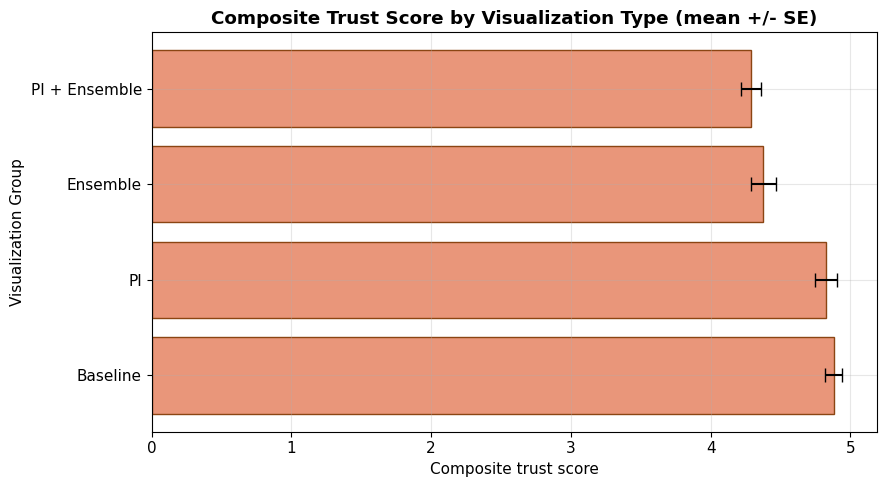

,visualization_group,n,mean_score,sd_score,se_score
0,Baseline,335,4.882,1.112,0.060755
1,PI,226,4.826,1.163,0.077362
2,Ensemble,221,4.377,1.308,0.087986
3,PI + Ensemble,335,4.288,1.355,0.074032


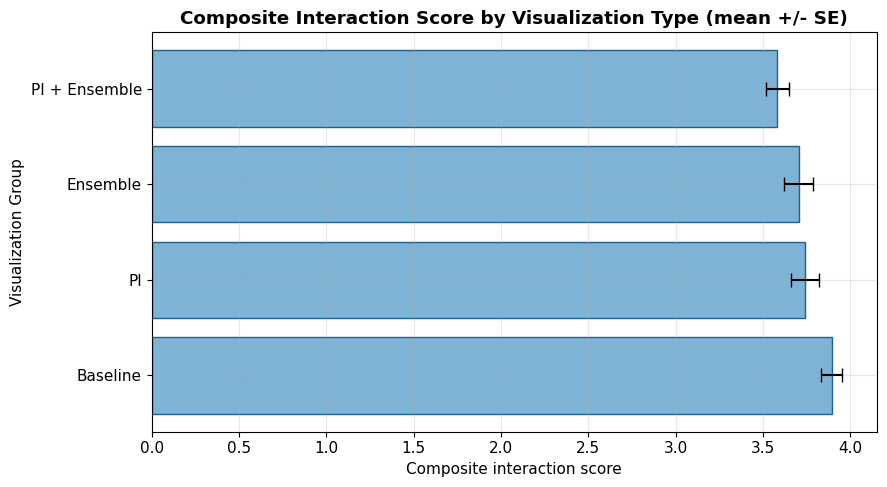

,visualization_group,n,mean_score,sd_score,se_score
0,Baseline,335,3.893,1.144,0.062503
1,PI,226,3.742,1.218,0.081020
2,Ensemble,221,3.705,1.220,0.082066
3,PI + Ensemble,335,3.583,1.208,0.066000


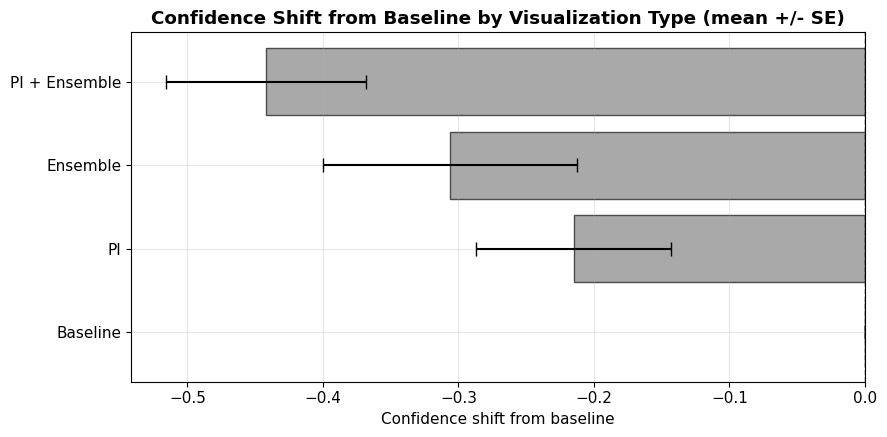

,visualization_group,n,mean_shift,sd_shift,se_shift,group_category
0,Baseline,335,0.000,0.000,0.000000,Baseline
1,PI,226,-0.215,1.080,0.071841,PI
2,Ensemble,221,-0.306,1.395,0.093838,Ensemble
3,PI + Ensemble,335,-0.442,1.350,0.073758,PI + Ensemble


In [116]:
VISUALIZATION_GROUP_MAP = {
    "Baseline": [1],
    "PI": [2, 5, 19],
    "Ensemble": [3, 4, 18],
    "PI + Ensemble": [6, 9, 20],
}

INTERACTION_GROUP_MAP = {
    "Baseline": [1],
    "Static": [2, 3, 9],
    "Interactive": [4, 5, 6],
    "Glitch": [18, 19, 20],
}

VISUALIZATION_GROUP_ORDER = ["Baseline", "PI", "Ensemble", "PI + Ensemble"]
INTERACTION_GROUP_ORDER = ["Baseline", "Static", "Interactive", "Glitch"]


def _to_int_condition(condition_value):
    if pd.isna(condition_value):
        return np.nan

    try:
        return int(float(condition_value))
    except (TypeError, ValueError):
        return np.nan


def _map_condition_to_group(condition_number, group_map):
    condition_id = _to_int_condition(condition_number)
    if pd.isna(condition_id):
        return np.nan

    for group_name, conditions in group_map.items():
        if int(condition_id) in conditions:
            return group_name

    return np.nan


def add_grouping_columns(data, group_map, group_col_name):
    if data is None or data.empty:
        return data.copy()

    grouped_data = data.copy()
    grouped_data["condition_number"] = pd.to_numeric(grouped_data["condition_number"], errors="coerce")
    grouped_data[group_col_name] = grouped_data["condition_number"].apply(
        lambda x: _map_condition_to_group(x, group_map)
    )

    return grouped_data.dropna(subset=[group_col_name]).copy()


def summarize_metric_by_group(data, value_col, group_col, label_name):
    if data.empty:
        print(f"No {label_name} rows available for grouping by {group_col}")
        return pd.DataFrame()

    summary = (
        data.groupby(group_col, dropna=False)
        .agg(
            n=("participant_id", "nunique"),
            mean_score=(value_col, "mean"),
            sd_score=(value_col, "std"),
        )
        .reset_index()
        .round(3)
    )
    summary["se_score"] = summary["sd_score"] / np.sqrt(summary["n"])
    return summary


def plot_group_summary(summary, value_col, error_col, group_col, x_label, title, order, color, edgecolor):
    if summary.empty:
        print(f"No data available for {title}")
        return

    summary = summary.copy()
    summary["group_category"] = pd.Categorical(summary[group_col], categories=order, ordered=True)
    summary = summary.sort_values("group_category").reset_index(drop=True)

    plt.figure(figsize=(9, 5))
    plt.barh(
        np.arange(len(summary)),
        summary[value_col],
        xerr=summary[error_col],
        color=color,
        edgecolor=edgecolor,
        capsize=5,
    )
    plt.yticks(np.arange(len(summary)), summary[group_col])
    plt.xlabel(x_label)
    plt.ylabel(group_col.replace("_", " ").title())
    plt.title(title, fontweight="bold")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def analyze_metric_by_group(data, group_map, group_col_name, value_col, value_label, x_label, title, order, color, edgecolor):
    grouped_data = add_grouping_columns(data, group_map, group_col_name)
    if grouped_data.empty:
        print(f"No rows found for {value_label} in these groups.")
        return pd.DataFrame(), pd.DataFrame()

    summary = summarize_metric_by_group(grouped_data, value_col, group_col_name, value_label)
    plot_group_summary(summary, "mean_score", "se_score", group_col_name, x_label, title, order, color, edgecolor)

    return grouped_data, summary.sort_values("mean_score", ascending=False).reset_index(drop=True)


def analyze_confidence_shift_by_group(phase1_data, phase2_data, group_map, group_col_name, order, title):
    if phase1_data.empty or phase2_data.empty:
        print("Missing phase data for confidence shift analysis")
        return pd.DataFrame(), pd.DataFrame()

    baseline = (
        phase1_data[["participant_id", "confidence_rating"]]
        .dropna(subset=["confidence_rating"])
        .groupby("participant_id", as_index=False)["confidence_rating"]
        .mean()
        .rename(columns={"confidence_rating": "baseline_confidence"})
    )

    phase2_conf = (
        phase2_data[["participant_id", "condition_number", "condition_name", "confidence_rating"]]
        .dropna(subset=["confidence_rating", "condition_number"])
        .copy()
    )

    if phase2_conf.empty and 1 not in {c for groups in group_map.values() for c in groups}:
        print("No phase 2 confidence rows available.")
        return pd.DataFrame(), pd.DataFrame()

    phase2_condition_summary = (
        phase2_conf
        .groupby(["participant_id", "condition_number", "condition_name"], as_index=False)
        ["confidence_rating"]
        .mean()
    )
    phase2_condition_summary["condition_number"] = pd.to_numeric(
        phase2_condition_summary["condition_number"], errors="coerce"
    )

    if any(1 in conds for conds in group_map.values()):
        baseline_rows = baseline.copy()
        baseline_rows["condition_number"] = 1
        baseline_rows["condition_name"] = "Baseline"
        baseline_rows["confidence_rating"] = baseline_rows["baseline_confidence"]
        baseline_rows = baseline_rows[["participant_id", "condition_number", "condition_name", "confidence_rating"]]
        phase2_condition_summary = pd.concat([phase2_condition_summary, baseline_rows], ignore_index=True)

    if phase2_condition_summary.empty:
        print("No phase 2 rows matched requested grouped conditions.")
        return pd.DataFrame(), pd.DataFrame()

    phase2_condition_summary[group_col_name] = phase2_condition_summary["condition_number"].apply(
        lambda x: _map_condition_to_group(x, group_map)
    )
    phase2_condition_summary = phase2_condition_summary.dropna(subset=[group_col_name]).copy()

    if phase2_condition_summary.empty:
        print("No phase 2 rows matched requested grouped conditions.")
        return pd.DataFrame(), pd.DataFrame()

    shift_data = phase2_condition_summary.merge(baseline, on="participant_id", how="inner")
    shift_data["confidence_shift"] = (
        shift_data["confidence_rating"] - shift_data["baseline_confidence"]
    )

    summary = (
        shift_data.groupby(group_col_name, as_index=False)
        .agg(
            n=("participant_id", "nunique"),
            mean_shift=("confidence_shift", "mean"),
            sd_shift=("confidence_shift", "std"),
        )
        .round(3)
    )
    summary["se_shift"] = summary["sd_shift"] / np.sqrt(summary["n"])

    ordered = summary.copy()
    ordered["group_category"] = pd.Categorical(summary[group_col_name], categories=order, ordered=True)
    ordered = ordered.sort_values("group_category").reset_index(drop=True)

    plt.figure(figsize=(9, 4.5))
    plt.barh(
        np.arange(len(ordered)),
        ordered["mean_shift"],
        xerr=ordered["se_shift"],
        color="#A9A9A9",
        edgecolor="#4B4B4B",
        capsize=5,
    )
    plt.yticks(np.arange(len(ordered)), ordered[group_col_name])
    plt.xlabel("Confidence shift from baseline")
    plt.title(title, fontweight="bold")
    plt.grid(True, axis="x", alpha=0.3)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.tight_layout()
    plt.show()

    return shift_data, ordered.sort_values("mean_shift", ascending=False).reset_index(drop=True)


viz_composite_trust_plot_data, viz_composite_trust_summary = analyze_metric_by_group(
    composite_trust_data,
    VISUALIZATION_GROUP_MAP,
    "visualization_group",
    value_col="composite_trust_score",
    value_label="Composite trust score",
    x_label="Composite trust score",
    title="Composite Trust Score by Visualization Type (mean +/- SE)",
    order=VISUALIZATION_GROUP_ORDER,
    color="#E9967A",
    edgecolor="#8B4513",
)

display(viz_composite_trust_summary)

viz_composite_interaction_plot_data, viz_composite_interaction_summary = analyze_metric_by_group(
    composite_interaction_data,
    VISUALIZATION_GROUP_MAP,
    "visualization_group",
    value_col="composite_interaction_score",
    value_label="Composite interaction score",
    x_label="Composite interaction score",
    title="Composite Interaction Score by Visualization Type (mean +/- SE)",
    order=VISUALIZATION_GROUP_ORDER,
    color="#7FB3D5",
    edgecolor="#1F618D",
)

display(viz_composite_interaction_summary)

viz_confidence_shift_plot_data, viz_confidence_shift_summary = analyze_confidence_shift_by_group(
    phase1_data,
    phase2_data,
    VISUALIZATION_GROUP_MAP,
    group_col_name="visualization_group",
    order=VISUALIZATION_GROUP_ORDER,
    title="Confidence Shift from Baseline by Visualization Type (mean +/- SE)",
)

display(viz_confidence_shift_summary)


## 7. Cross-Interaction Availability Analysis (Baseline, Static, Interactive, Glitch)

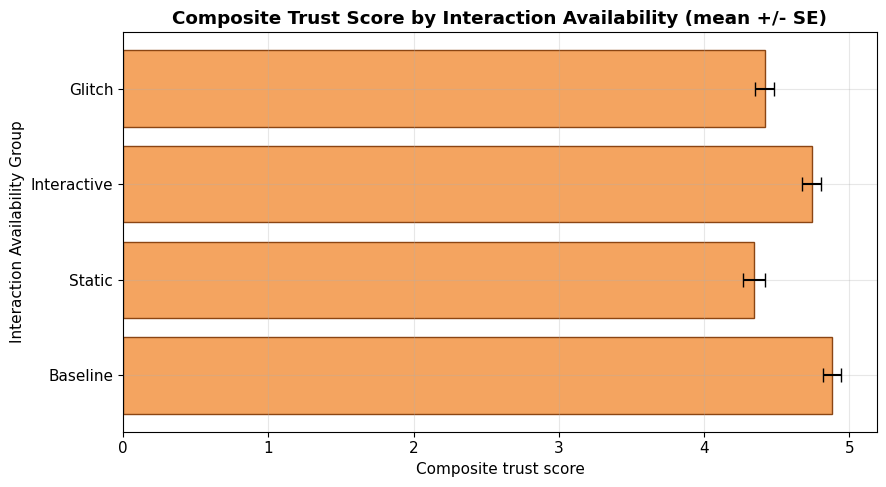

,interaction_availability_group,n,mean_score,sd_score,se_score
0,Baseline,335,4.882,1.112,0.060755
1,Interactive,335,4.740,1.197,0.065399
2,Glitch,335,4.416,1.237,0.067585
3,Static,335,4.342,1.418,0.077474


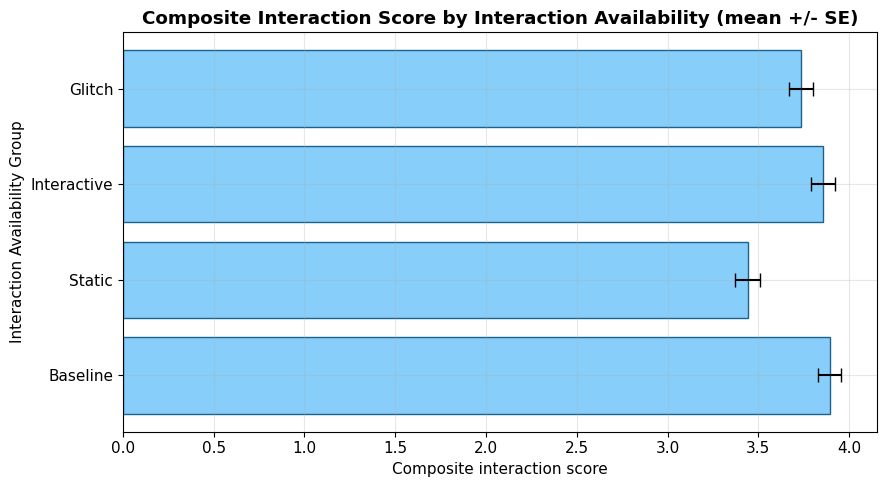

,interaction_availability_group,n,mean_score,sd_score,se_score
0,Baseline,335,3.893,1.144,0.062503
1,Interactive,335,3.856,1.186,0.064798
2,Glitch,335,3.734,1.183,0.064634
3,Static,335,3.441,1.244,0.067967


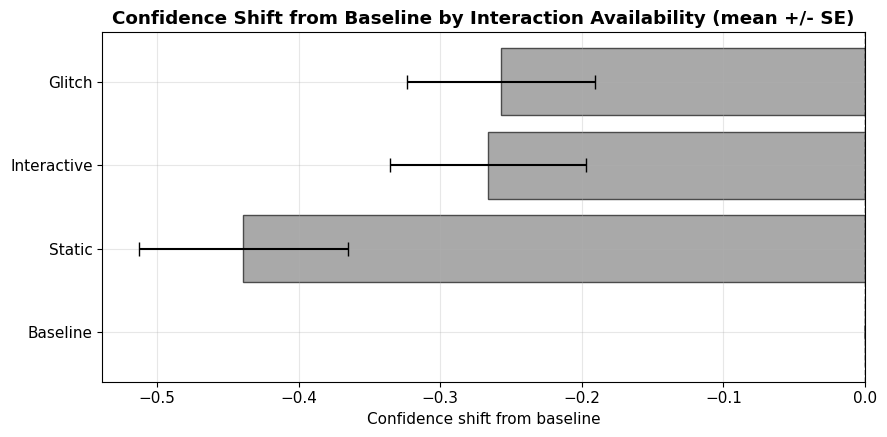

,interaction_availability_group,n,mean_shift,sd_shift,se_shift,group_category
0,Baseline,335,0.000,0.000,0.000000,Baseline
1,Glitch,335,-0.257,1.219,0.066601,Glitch
2,Interactive,335,-0.266,1.268,0.069278,Interactive
3,Static,335,-0.439,1.354,0.073977,Static


In [117]:
interaction_composite_trust_plot_data, interaction_composite_trust_summary = analyze_metric_by_group(
    composite_trust_data,
    INTERACTION_GROUP_MAP,
    "interaction_availability_group",
    value_col="composite_trust_score",
    value_label="Composite trust score",
    x_label="Composite trust score",
    title="Composite Trust Score by Interaction Availability (mean +/- SE)",
    order=INTERACTION_GROUP_ORDER,
    color="#F4A460",
    edgecolor="#8B4513",
)

display(interaction_composite_trust_summary)

interaction_composite_interaction_plot_data, interaction_composite_interaction_summary = analyze_metric_by_group(
    composite_interaction_data,
    INTERACTION_GROUP_MAP,
    "interaction_availability_group",
    value_col="composite_interaction_score",
    value_label="Composite interaction score",
    x_label="Composite interaction score",
    title="Composite Interaction Score by Interaction Availability (mean +/- SE)",
    order=INTERACTION_GROUP_ORDER,
    color="#87CEFA",
    edgecolor="#1F618D",
)

display(interaction_composite_interaction_summary)

interaction_confidence_shift_plot_data, interaction_confidence_shift_summary = analyze_confidence_shift_by_group(
    phase1_data,
    phase2_data,
    INTERACTION_GROUP_MAP,
    group_col_name="interaction_availability_group",
    order=INTERACTION_GROUP_ORDER,
    title="Confidence Shift from Baseline by Interaction Availability (mean +/- SE)",
)

display(interaction_confidence_shift_summary)
